## <center>Prediction of the winner of a tennis match - Siwar ABBES</center> 
------------------------------------------------------------------------------------------------------------------
<img src="static/images/tennis_notebook.jpg" width="800" height="600">


------------------------------------------------------------------------------------------------------------------
**The aim of this work** is to explore data from ATP tennis competitions in order to predict the results of tennis matches.
1. [Import Librairies](#Importation)
2. [Data Exploration](#EDA)
3. [Feature Engineering](#engineering)
4. [Model Choice](#model)
5. [Fine Tuning and Train](#train)
6. [Evaluation](#predict)
6. [Conclusion](#conclusion)
------------------------------------------------------------------------------------------------------------------


<a id='Importation'></a>
### 1.  Import Librairies

In [1]:
import warnings
from time import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set(rc={'figure.figsize':(8,6)})
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import json

import shap
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import KFold, GridSearchCV, TimeSeriesSplit

import numpy as np
np.random.seed(7)


In [2]:
from pandas_profiling import ProfileReport

<a id='EDA'></a>
### 2. Data Exploration

In [3]:
data = pd.read_csv("data/ATP_tweaked.csv", sep = ';')
print('The data shape is : ', data.shape)
print('\nThe data columns are : ', data.columns.values)
data.head()

The data shape is :  (12310, 49)

The data columns are :  ['best_of' 'p2_1stIn' 'p2_1stWon' 'p2_2ndWon' 'p2_SvGms' 'p2_ace'
 'p2_bpFaced' 'p2_bpSaved' 'p2_df' 'p2_svpt' 'p2_age' 'p2_entry' 'p2_hand'
 'p2_ht' 'p2_id' 'p2_ioc' 'p2_name' 'p2_rank' 'p2_rank_points' 'p2_seed'
 'match_num' 'minutes' 'round' 'score' 'surface' 'tourney_date'
 'tourney_id' 'tourney_level' 'tourney_name' 'p1_1stIn' 'p1_1stWon'
 'p1_2ndWon' 'p1_SvGms' 'p1_ace' 'p1_bpFaced' 'p1_bpSaved' 'p1_df'
 'p1_svpt' 'p1_age' 'p1_entry' 'p1_hand' 'p1_ht' 'p1_id' 'p1_ioc'
 'p1_name' 'p1_rank' 'p1_rank_points' 'p1_seed' 'p1_won']


,best_of,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_ace,p2_bpFaced,p2_bpSaved,p2_df,p2_svpt,...,p1_entry,p1_hand,p1_ht,p1_id,p1_ioc,p1_name,p1_rank,p1_rank_points,p1_seed,p1_won
0,3,66.0,47.0,26.0,15.0,9.0,9.0,8.0,6.0,112.0,...,NaN,R,188.0,104542,FRA,Jo Wilfried Tsonga,19.0,1645.0,NaN,0
1,3,45.0,33.0,21.0,13.0,6.0,9.0,6.0,5.0,87.0,...,NaN,R,NaN,105526,GER,Jan Lennard Struff,89.0,650.0,NaN,1
2,5,54.0,38.0,21.0,18.0,3.0,4.0,0.0,3.0,92.0,...,NaN,R,183.0,104527,SUI,Stanislas Wawrinka,5.0,5710.0,5.0,1
3,3,46.0,35.0,17.0,14.0,2.0,2.0,0.0,3.0,72.0,...,NaN,R,180.0,104655,URU,Pablo Cuevas,23.0,1447.0,6.0,0
4,3,42.0,33.0,13.0,11.0,10.0,1.0,0.0,1.0,68.0,...,Q,R,185.0,104433,CAN,Frank Dancevic,156.0,326.0,NaN,0


In [4]:
#ProfileReport(data)

In [5]:
data.describe()

,best_of,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_ace,p2_bpFaced,p2_bpSaved,p2_df,p2_svpt,...,p1_bpSaved,p1_df,p1_svpt,p1_age,p1_ht,p1_id,p1_rank,p1_rank_points,p1_seed,p1_won
count,12310.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,...,11902.000000,11902.000000,11902.000000,12301.00000,9222.000000,12310.000000,12203.000000,12203.000000,4169.000000,12310.00000
mean,3.449553,49.557889,35.638800,16.104352,12.725004,6.597463,6.754243,4.117711,3.088052,81.201563,...,4.103428,3.107881,81.249202,27.77952,186.566580,107720.937043,97.749078,1464.070556,7.961861,0.50000
std,0.834904,19.340074,14.466661,7.167955,4.322233,5.767244,4.481091,3.250747,2.437863,29.776454,...,3.245153,2.461629,29.739695,4.42404,7.680804,11520.722732,173.310839,1906.471819,7.071728,0.50002
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,16.28000,163.000000,100644.000000,1.000000,1.000000,1.000000,0.00000
25%,3.000000,36.000000,25.000000,11.000000,10.000000,3.000000,3.000000,2.000000,1.000000,59.000000,...,2.000000,1.000000,59.000000,24.77000,183.000000,104607.000000,25.000000,581.500000,3.000000,0.00000
50%,3.000000,46.000000,33.000000,15.000000,12.000000,5.000000,6.000000,4.000000,3.000000,76.000000,...,4.000000,3.000000,76.000000,28.03000,185.000000,105223.000000,54.000000,877.000000,6.000000,0.50000
75%,3.000000,60.000000,43.000000,20.000000,15.000000,9.000000,9.000000,6.000000,4.000000,98.000000,...,6.000000,4.000000,98.000000,30.94000,190.000000,105967.000000,96.000000,1515.000000,10.000000,1.00000
max,5.000000,218.000000,171.000000,54.000000,50.000000,75.000000,30.000000,24.000000,21.000000,291.000000,...,25.000000,19.000000,278.000000,46.05000,208.000000,207972.000000,2147.000000,16790.000000,33.000000,1.00000


The data set contains the details about all the ATP matches played.

General
- tourneyid - tournamentid
- tourneyname - tournamentname
- surface - surface in which the match is played
- draw_size - the size of the draw
- tourney_level - tournament level
    - 'G' = Grand Slams
    - 'M' = Masters 1000s
    - 'A' = other tour-level events
    - 'C' = Challengers
    - 'S' = Satellites/ITFs
    - 'F' = Tour finals and other season-ending events
    - 'D' = Davis Cup
- tourney_date - starting date of the tournament
- match num - match number in a certain tournament
Players
- [prefixes : P1_ - info about player 1, P2_ - info about player 2]
- id - player id
- seed - the seed of the player in that tournament
- entry - How did the player enter the tournaments?
    - WC - Wildcard
    - Q - Qualifier
    - LL - Lucky loser
    - PR - Protected ranking
    - SE - Special Exempt
    - ALT - Alternate player
- name - player name
- hand - hand of the player, right or left
- ht - the height of the player
- IOC - the country of origin
- age - age of the player
- score - final score in the match
- best_of - the maximum number of sets played
- round - the round in the tournament a match belongs to
- minutes - duration of the match in minutes
- ace - number of aces in the match
- df - double faults
- svpt - serve percent
- 1stin - first serve in percent
- 1stWon - first serve winning percent
- 2ndWon - second serve winning percent
- SvGms - number of games played on serve (So, the maximum difference between
wSvGms and lSvGms will be 1)
- bpSaved - breakpoints save
- bpFaced - breakpoints faced
- p1_won : first player won

In [6]:
print('The data columns types are :\n \n', data.dtypes)

The data columns types are :
 
 best_of             int64
p2_1stIn          float64
p2_1stWon         float64
p2_2ndWon         float64
p2_SvGms          float64
p2_ace            float64
p2_bpFaced        float64
p2_bpSaved        float64
p2_df             float64
p2_svpt           float64
p2_age            float64
p2_entry           object
p2_hand            object
p2_ht             float64
p2_id               int64
p2_ioc             object
p2_name            object
p2_rank           float64
p2_rank_points    float64
p2_seed           float64
match_num           int64
minutes           float64
round              object
score              object
surface            object
tourney_date        int64
tourney_id         object
tourney_level      object
tourney_name       object
p1_1stIn          float64
p1_1stWon         float64
p1_2ndWon         float64
p1_SvGms          float64
p1_ace            float64
p1_bpFaced        float64
p1_bpSaved        float64
p1_df             float64
p1_svp

--------------------------------------------------------------------------------------------
### Explore the target
As we can notice, this ML project is a supervised binary classification where our target feature called p1_won can have 2 values :

- p1_won = 1 : The first player won the match.
- p1_won = 0 : The second player won the match..

Missing values for the target: 0
Target value : 0  ---- Frequency in the data set :  6155
Target value : 1  ---- Frequency in the data set :  6155


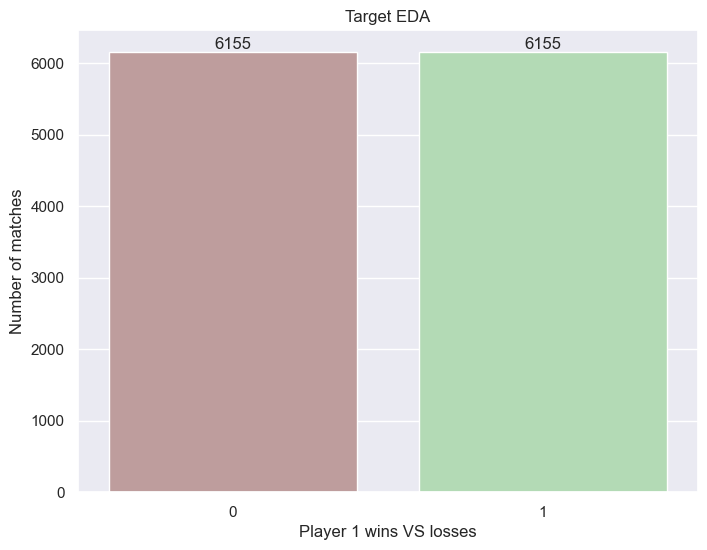

In [7]:
# Explore the target
print("Missing values for the target:", data["p1_won"].isnull().sum())

print('Target value :', 0, ' ---- Frequency in the data set : ', data['p1_won'].value_counts()[0])
print('Target value :', 1, ' ---- Frequency in the data set : ', data['p1_won'].value_counts()[1])

ax= sns.countplot(x='p1_won', data=data, palette=["#c39797", "#ace1af"])
ax.bar_label(ax.containers[0])
ax.set_title('Target EDA')
ax.set_xlabel('Player 1 wins VS losses')
ax.set_ylabel('Number of matches')
plt.show()

Good news, the dataset is **balanced.** 

--------------------------------------------------------------------------------------------
### Correlation

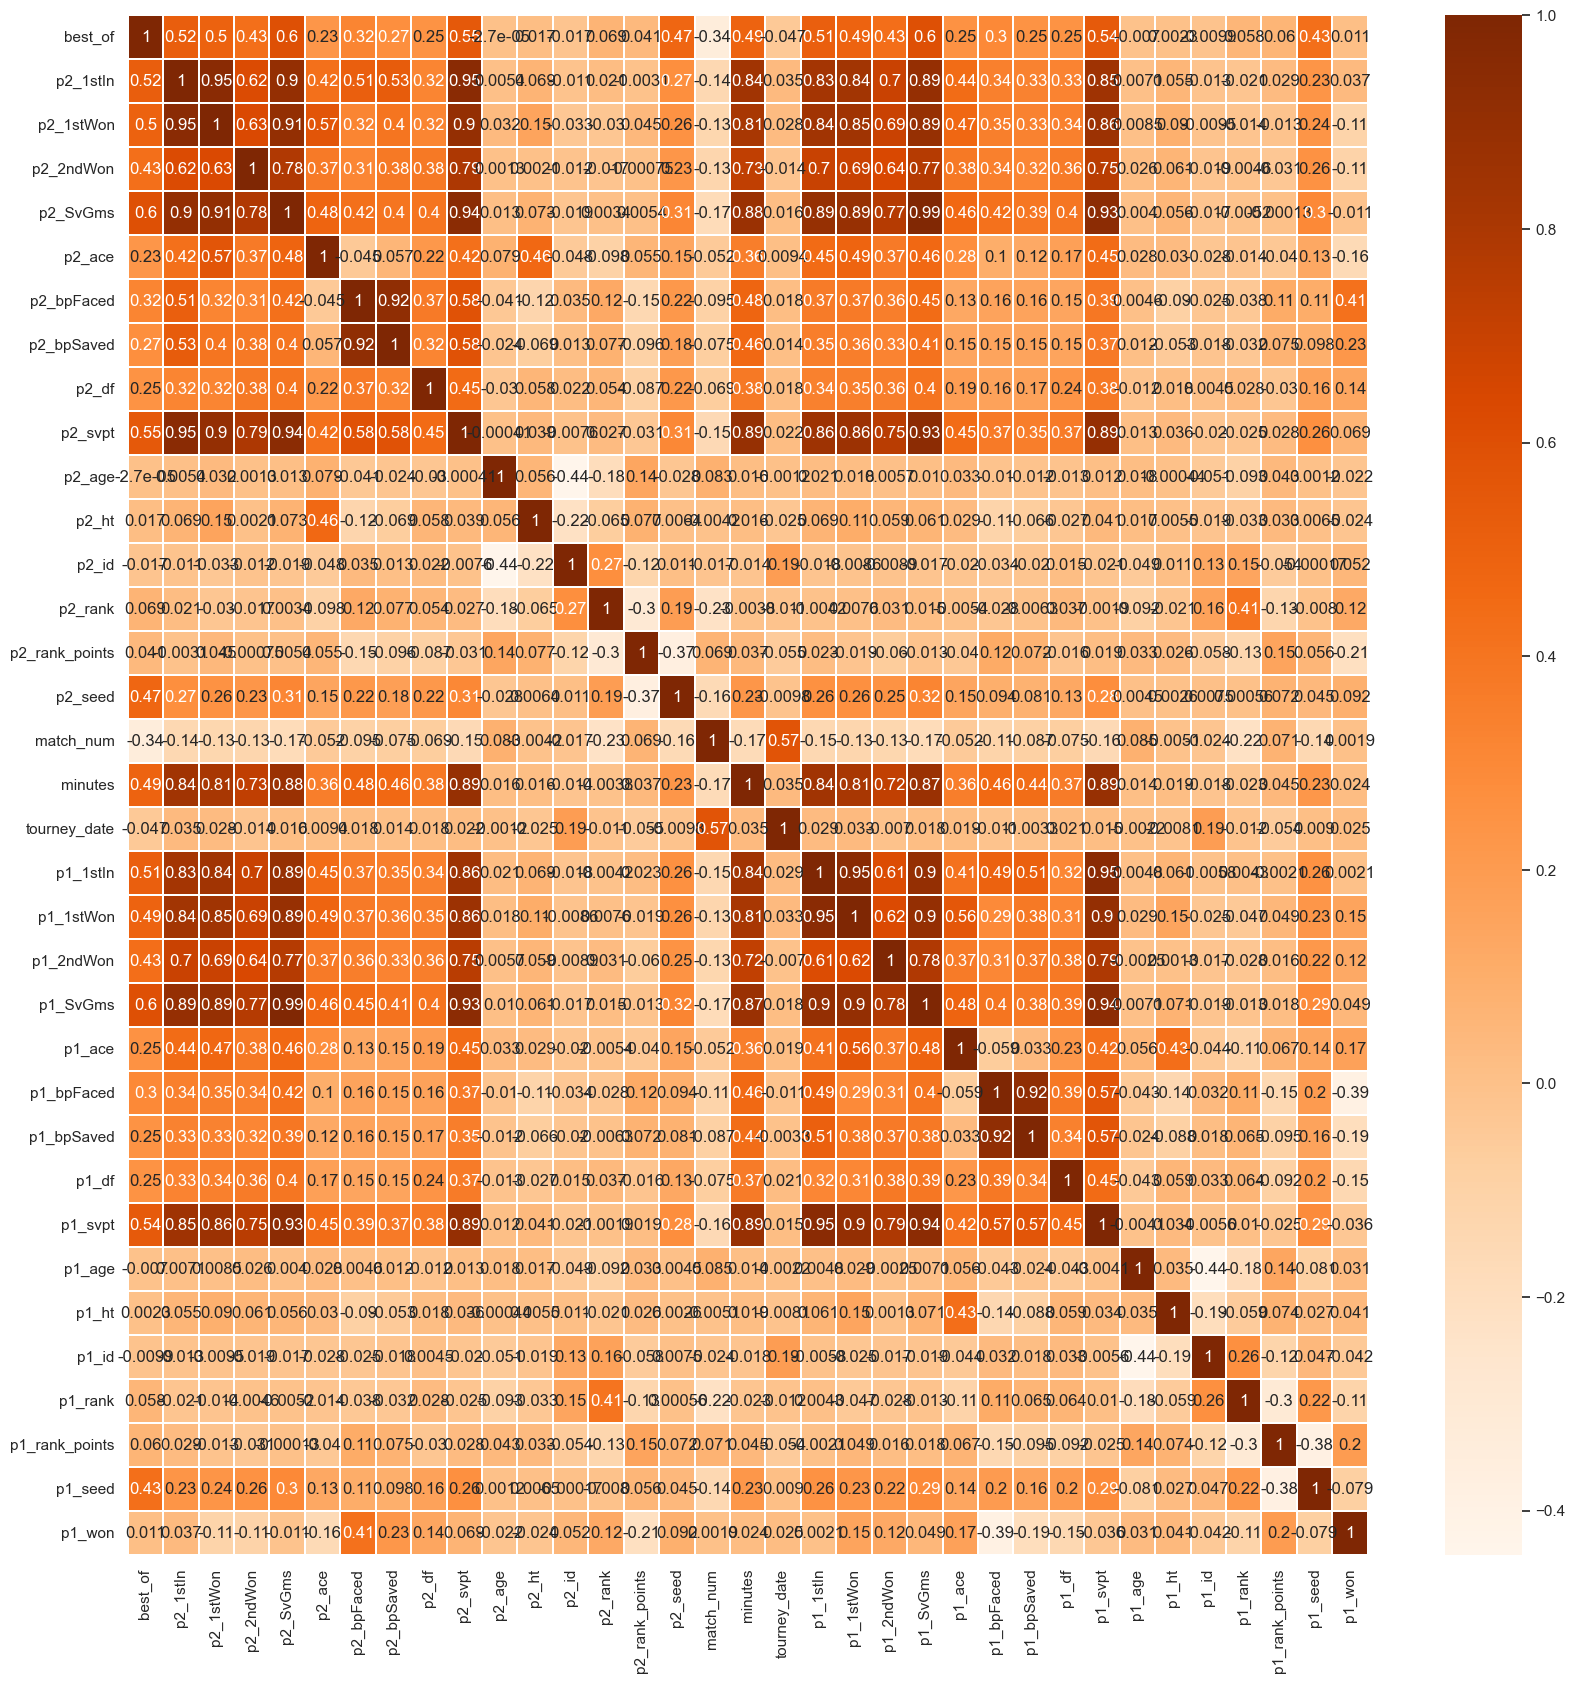

In [8]:
correlation_matrix = data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, annot= True, linewidth=0.1, cmap= 'Oranges')
plt.show()

We can see clearly that there many features highly correlated. This is expected because they represent the result of a match.
Let's clean the data and proceed to the removal of features that are obviously not available before a match to predict.



In [9]:
features_to_drop = [ 'minutes', 'score', 'p1_1stIn', 'p2_1stIn', 'p1_1stWon', 'p2_1stWon', 'p1_2ndWon', 'p2_2ndWon',
                     'p1_SvGms', 'p2_SvGms', 'p1_svpt','p2_svpt', 'p1_bpFaced', 'p2_bpFaced', 'p1_bpSaved', 
                     'p2_bpSaved','p1_ace','p2_ace','p1_df', 'p2_df']


print(f'Features to drop: {features_to_drop}')
data.drop(columns=features_to_drop, axis=1, inplace=True)

Features to drop: ['minutes', 'score', 'p1_1stIn', 'p2_1stIn', 'p1_1stWon', 'p2_1stWon', 'p1_2ndWon', 'p2_2ndWon', 'p1_SvGms', 'p2_SvGms', 'p1_svpt', 'p2_svpt', 'p1_bpFaced', 'p2_bpFaced', 'p1_bpSaved', 'p2_bpSaved', 'p1_ace', 'p2_ace', 'p1_df', 'p2_df']


--------------------------------------------------------------------------------------------

###  Categorical features

In [10]:
# features with number of distinct values
features = {c: data[c].nunique() for c in data.columns}
features_with_nb_categories ={k:v for k, v in sorted(features.items(), key=lambda item: item[1])} 
features_with_nb_categories

{'best_of': 2,
 'p1_won': 2,
 'p2_hand': 3,
 'p1_hand': 3,
 'surface': 5,
 'tourney_level': 5,
 'p1_entry': 6,
 'p2_entry': 7,
 'round': 9,
 'p2_ht': 19,
 'p1_ht': 19,
 'p2_seed': 33,
 'p1_seed': 33,
 'p1_ioc': 86,
 'p2_ioc': 88,
 'tourney_date': 179,
 'match_num': 343,
 'tourney_name': 374,
 'tourney_id': 579,
 'p1_id': 628,
 'p1_name': 628,
 'p2_id': 657,
 'p2_name': 657,
 'p2_rank': 683,
 'p1_rank': 716,
 'p1_age': 1914,
 'p2_age': 1928,
 'p2_rank_points': 1964,
 'p1_rank_points': 1987}

- **We will focus on these catgorical features** 
        - Best_of : [3, 5]
        - pi_hand : ['L', 'R', 'U']   # U: Unkonwn
        - surface : ['Hard', 'Grass', 'Clay', 'None', 'Carpet'] # None
        - tourney_level : ['M', 'A', 'G', 'D', 'F']  # A : other tour-level events
        - round : ['R64', 'R32', 'R16', 'QF', 'R128', 'SF', 'F', 'RR', 'BR']
        - p1_ioc : The country of origin ['FRA', 'GER', 'SUI', 'URU', 'CAN', 'USA' ...] (88 countries)
        - pi_name/pi_id : 675 players

**Winner name**

In [11]:
df_eda = data.copy()
df_eda['winner_name'] = np.where(df_eda['p1_won'] == 1, df_eda['p1_name'], df_eda['p2_name'])
df_eda[[ 'p1_name', 'p2_name', 'p1_won', 'winner_name']].head()

,p1_name,p2_name,p1_won,winner_name
0,Jo Wilfried Tsonga,Fernando Verdasco,0,Fernando Verdasco
1,Jan Lennard Struff,Marcos Baghdatis,1,Jan Lennard Struff
2,Stanislas Wawrinka,Donald Young,1,Stanislas Wawrinka
3,Pablo Cuevas,Rafael Nadal,0,Rafael Nadal
4,Frank Dancevic,Igor Sijsling,0,Igor Sijsling


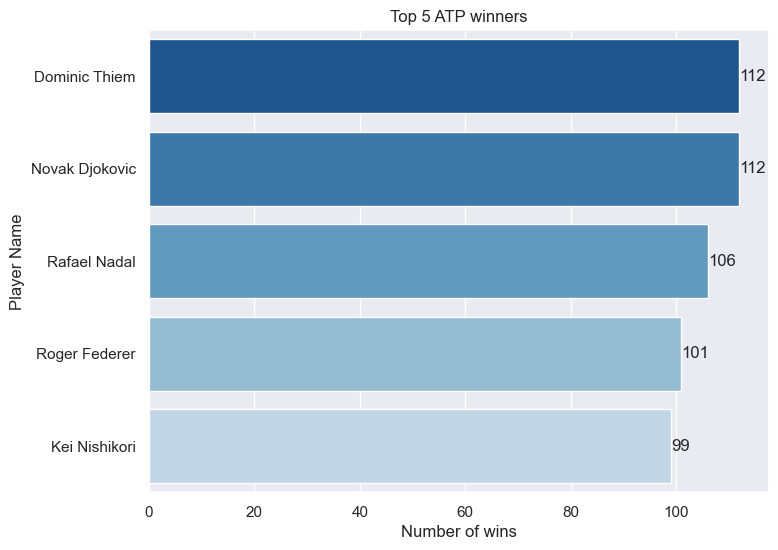

In [12]:
order = df_eda.groupby('winner_name').agg({'p1_won':'sum'})
order = order.apply(lambda x: x.sort_values(ascending=False)[:5])
order = order.reset_index()
# The three (3) ATP players with most wins
palette = sns.color_palette("Blues_r")
ax = sns.barplot(x="p1_won", y="winner_name", data=order, palette=np.array(palette)[order.index])
ax.bar_label(ax.containers[0])
ax.set_title('Top 5 ATP winners')
ax.set_ylabel('Player Name')
ax.set_xlabel('Number of wins')
plt.show()

The players who won the most matches are the most likely to win again. For further work, we can focus on top three and investigate the impact of other features like surface on the performance of these players or we can visualize their evolution across time. Of course, we can do that for any player.


#### player hand


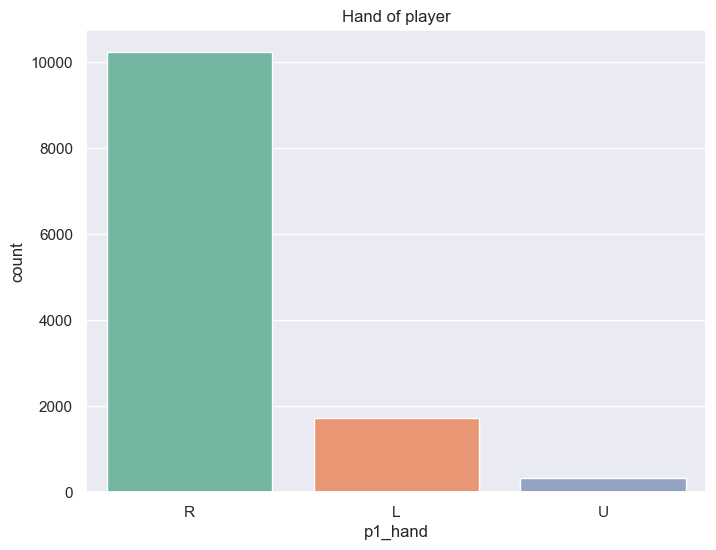

In [13]:
ax = sns.countplot(x='p1_hand', data=data, palette=sns.color_palette("Set2"))
ax.set_title("Hand of player")
plt.show()

As we can notice here, most of players use their right hand which is evident, and as we already have an extra class "U", we will use it to impute missing values

#### Tournament level


In [14]:
data.tourney_level.unique()

array(['M', 'A', 'G', 'D', 'F'], dtype=object)

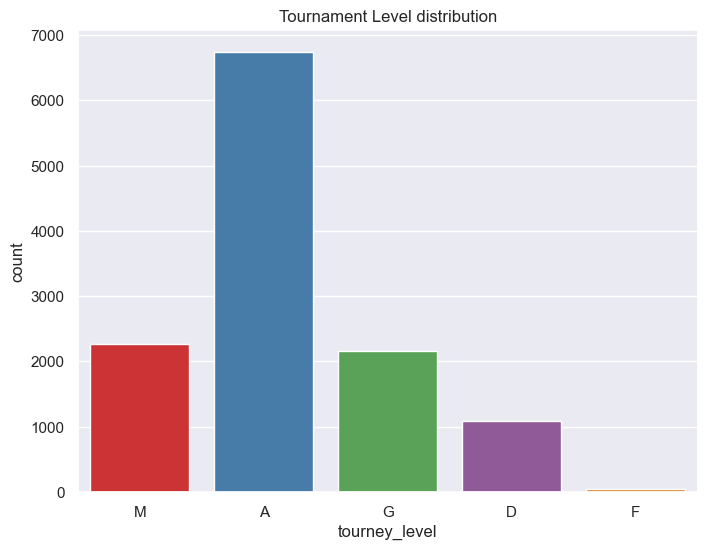

In [15]:
ax = sns.countplot(x='tourney_level', data=data, palette=sns.color_palette("Set1"))
ax.set_title("Tournament Level distribution")
plt.show()

    - 'G' = Grand Slams
    - 'M' = Masters 1000s
    - 'A' = other tour-level events
    - 'C' = Challengers
    - 'S' = Satellites/ITFs
    - 'F' = Tour finals and other season-ending events
    - 'D' = Davis Cup

As we can notice here, there are not data for S and C tournament levels in our data and we can use 'A' category to impute missing values

#### Surface Type

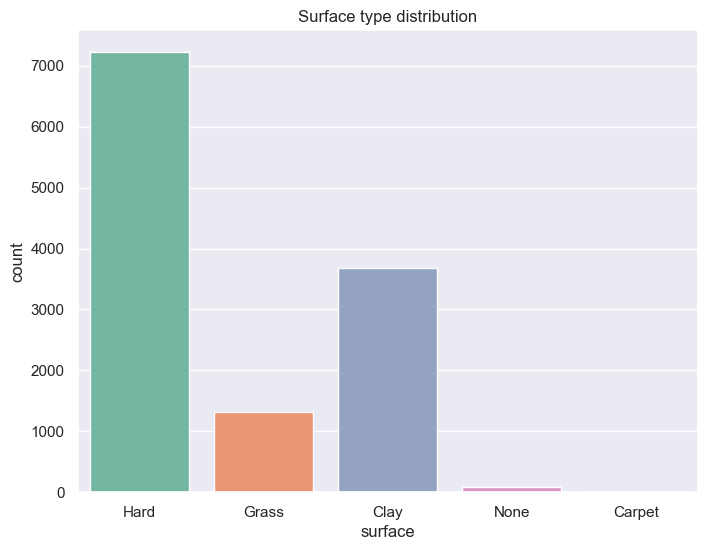

In [16]:
ax = sns.countplot(x="surface", data=data, palette=sns.color_palette("Set2"))
ax.set_title("Surface type distribution")
plt.show()

As we can notice, most of matches were played on hard surface and rarely on carpet surface.

### Numerical features


The mean value is : 27.74
The median value is : 27.94


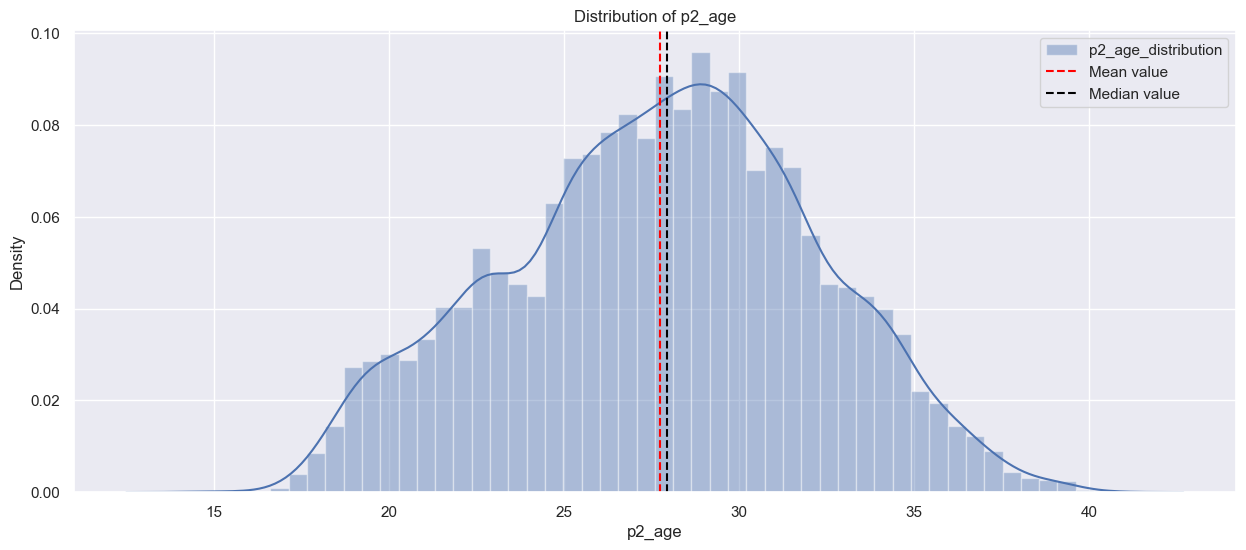

The mean value is : 186.64
The median value is : 185.0


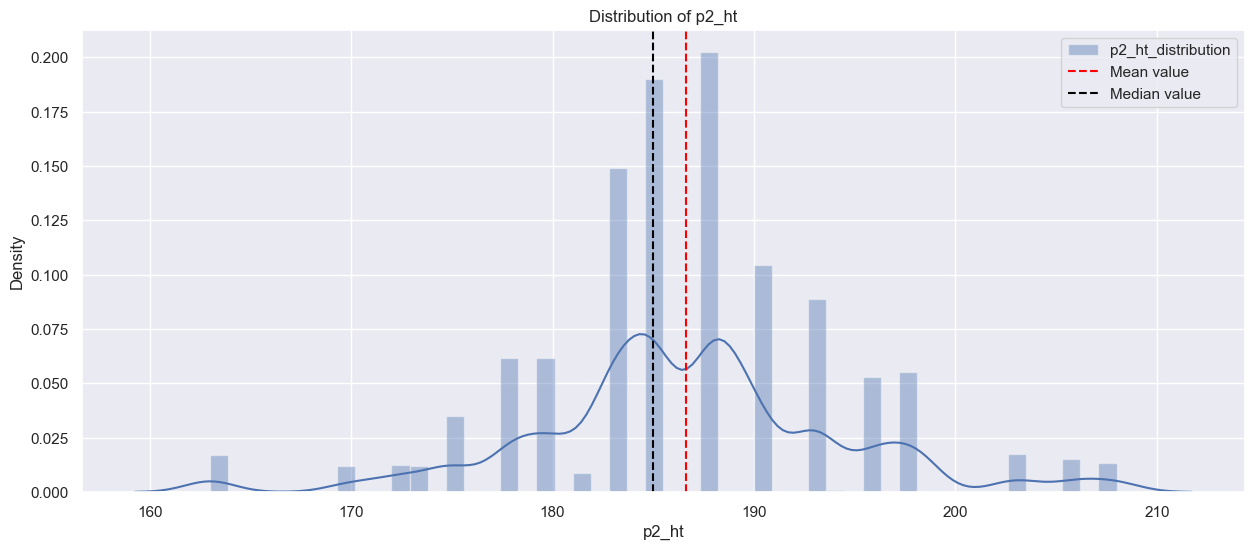

The mean value is : 96.39
The median value is : 55.0


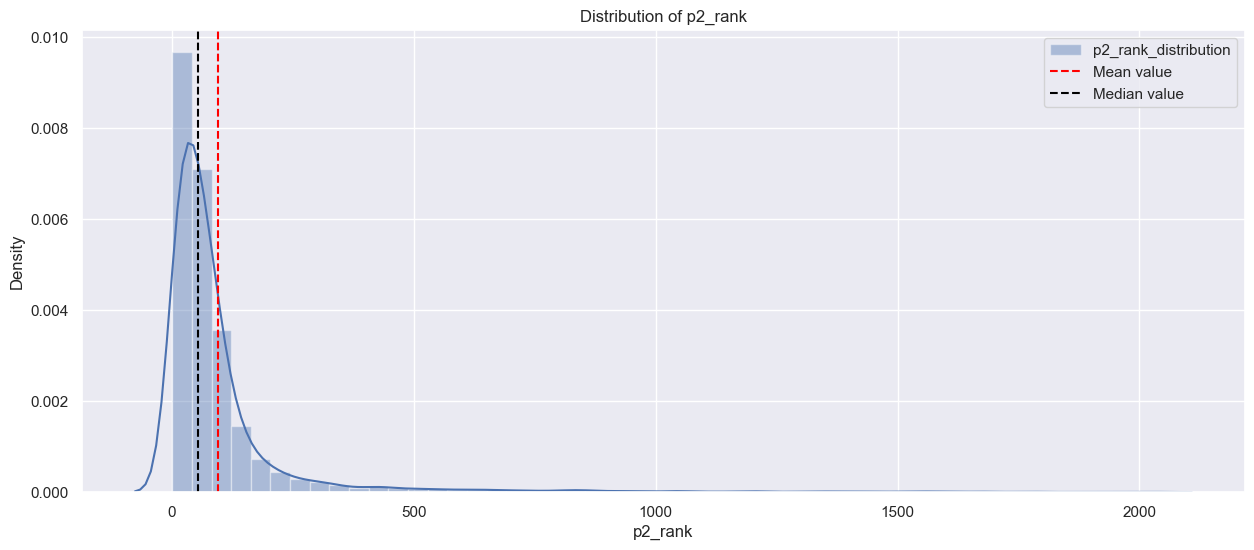

The mean value is : 1448.07
The median value is : 871.5


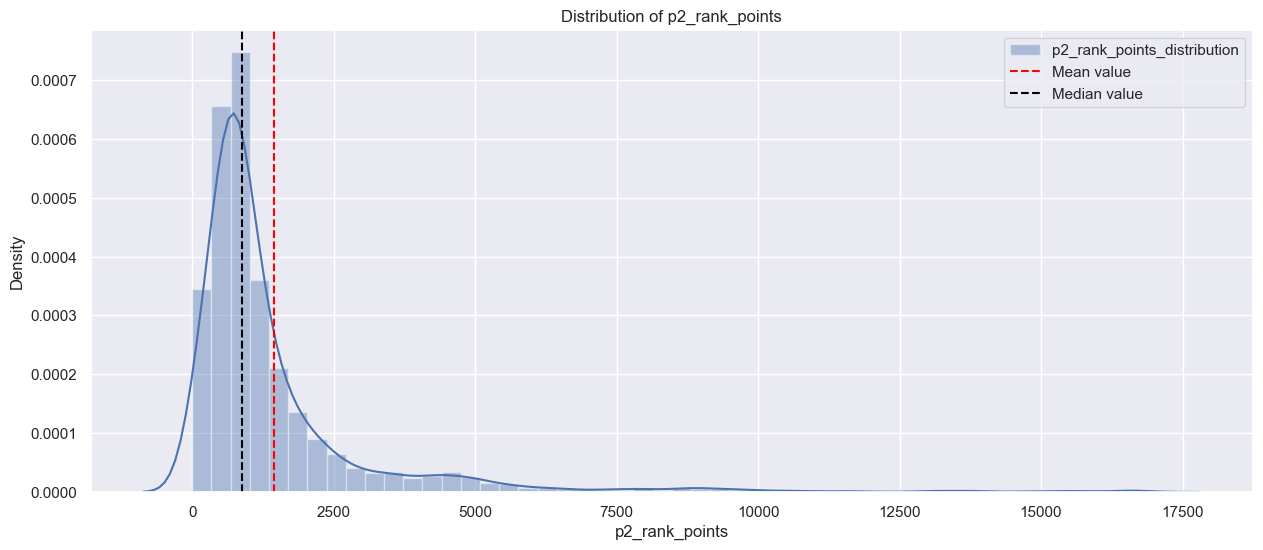

The mean value is : 7.97
The median value is : 6.0


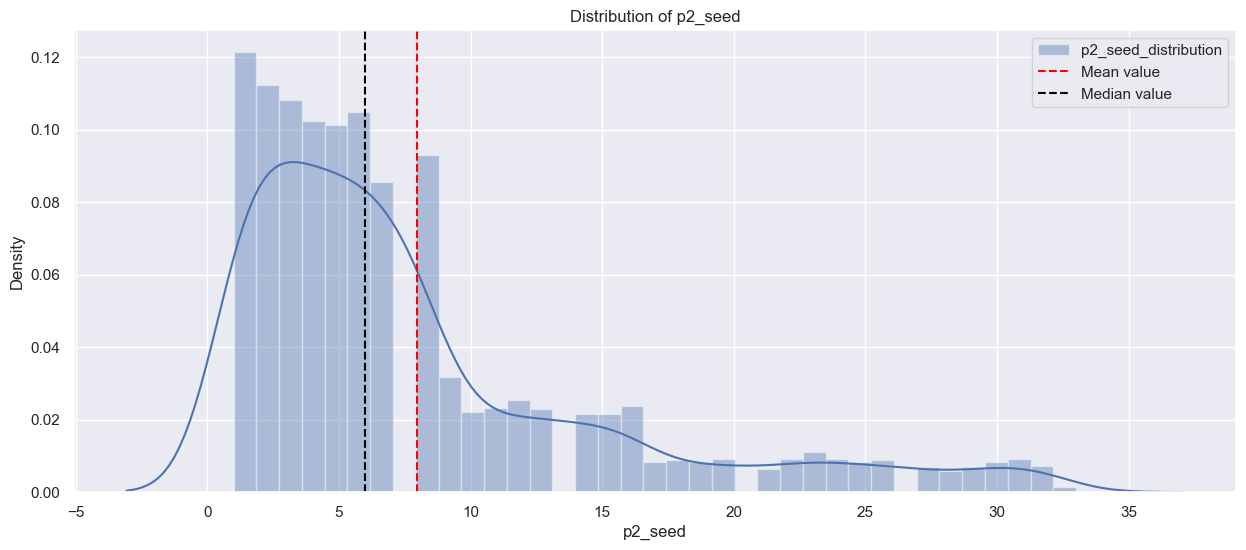

The mean value is : 186.35
The median value is : 260.0


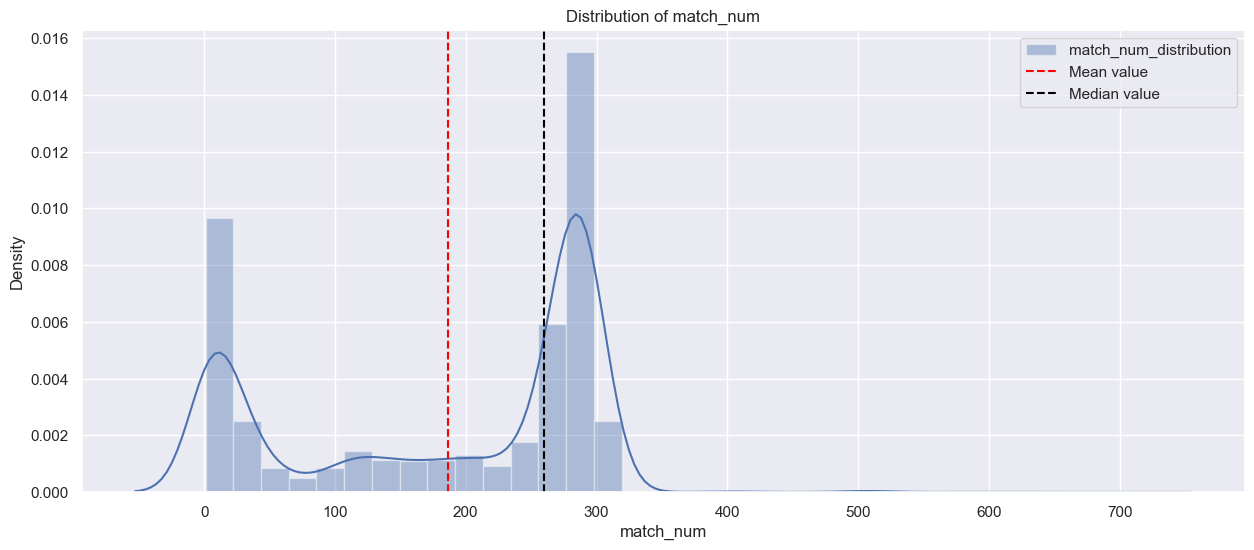

The mean value is : 27.78
The median value is : 28.03


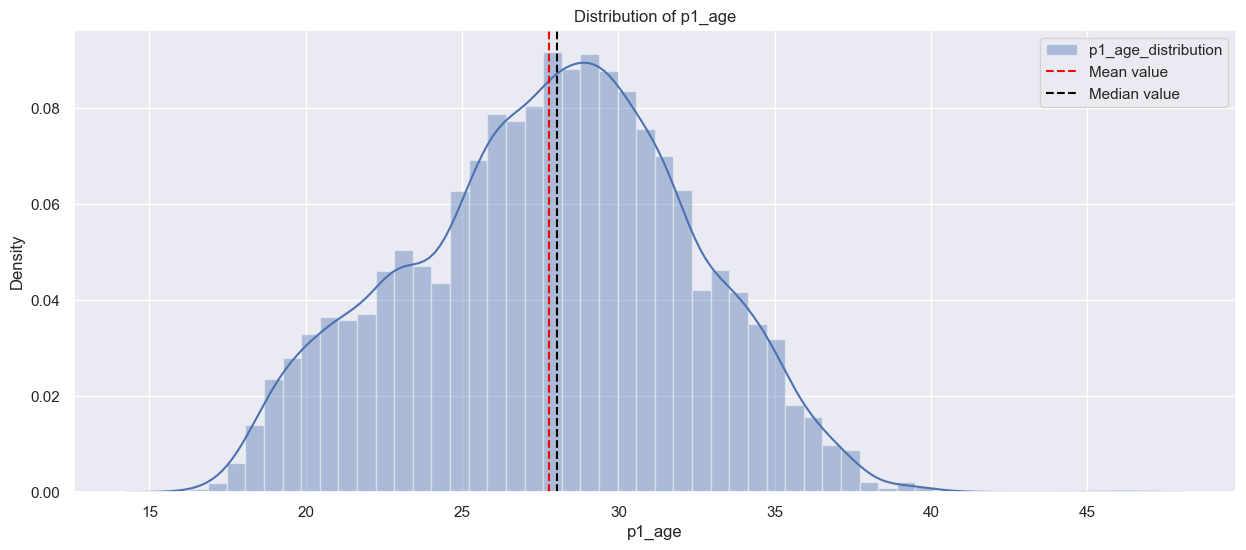

The mean value is : 186.57
The median value is : 185.0


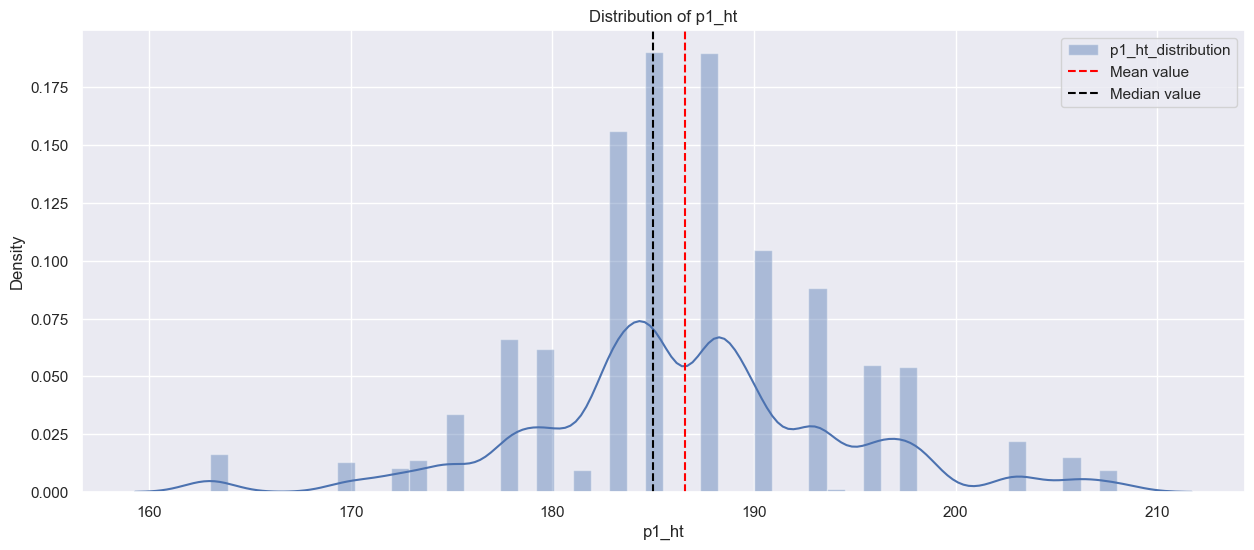

The mean value is : 107720.94
The median value is : 105223.0


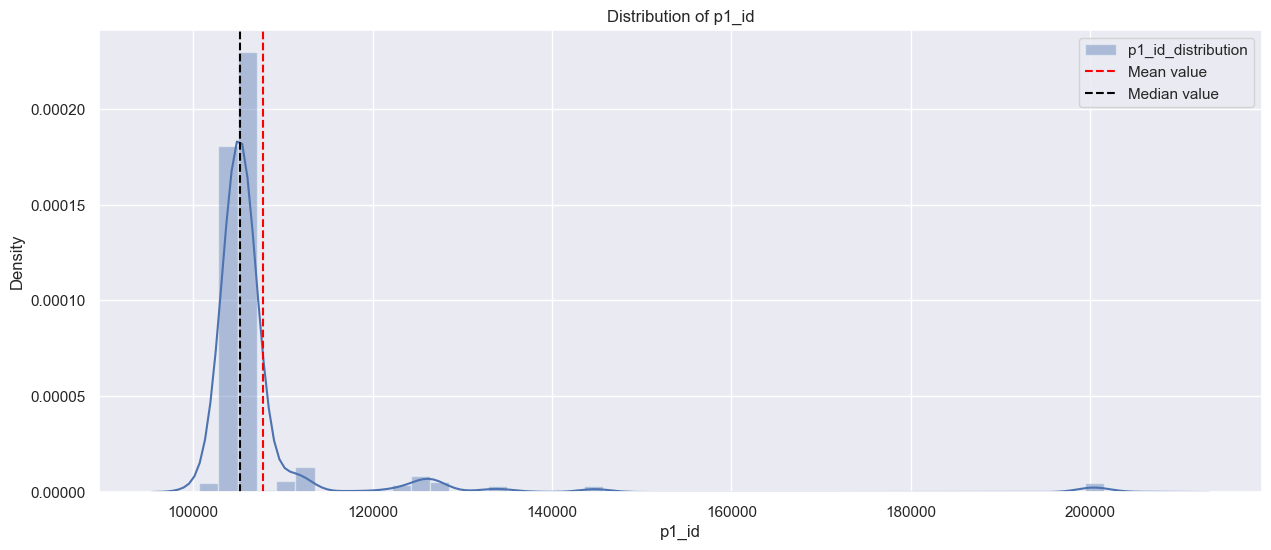

The mean value is : 97.75
The median value is : 54.0


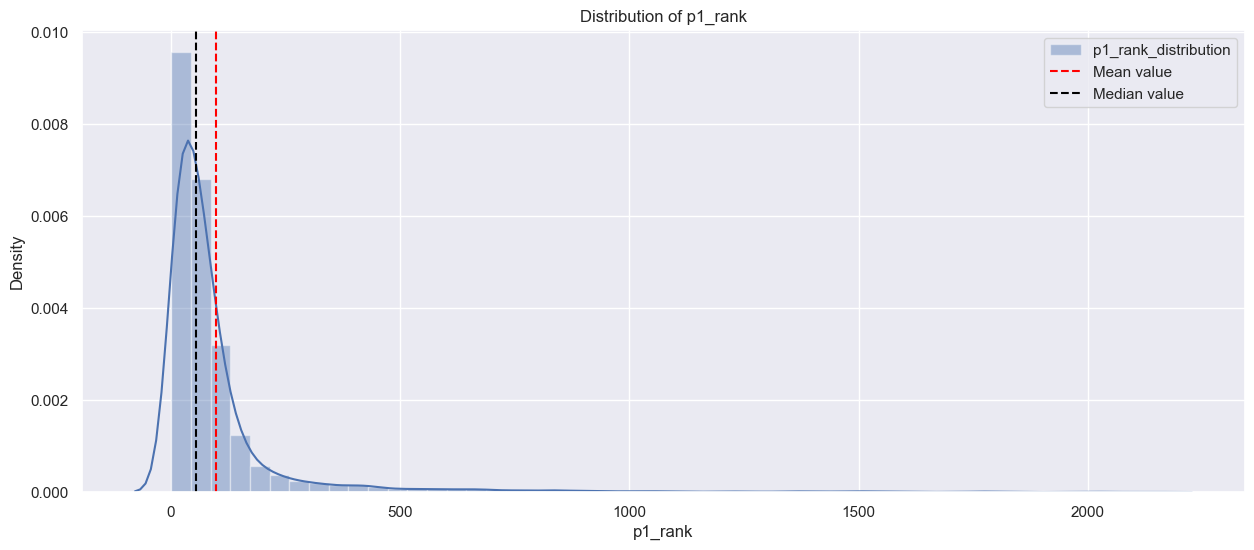

The mean value is : 1464.07
The median value is : 877.0


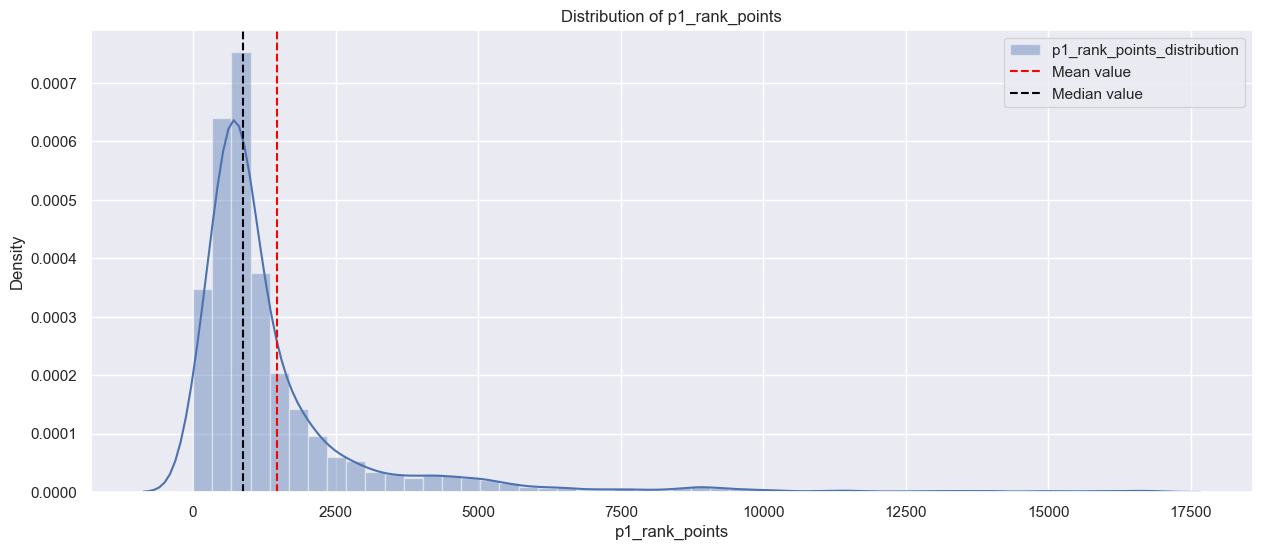

The mean value is : 7.96
The median value is : 6.0


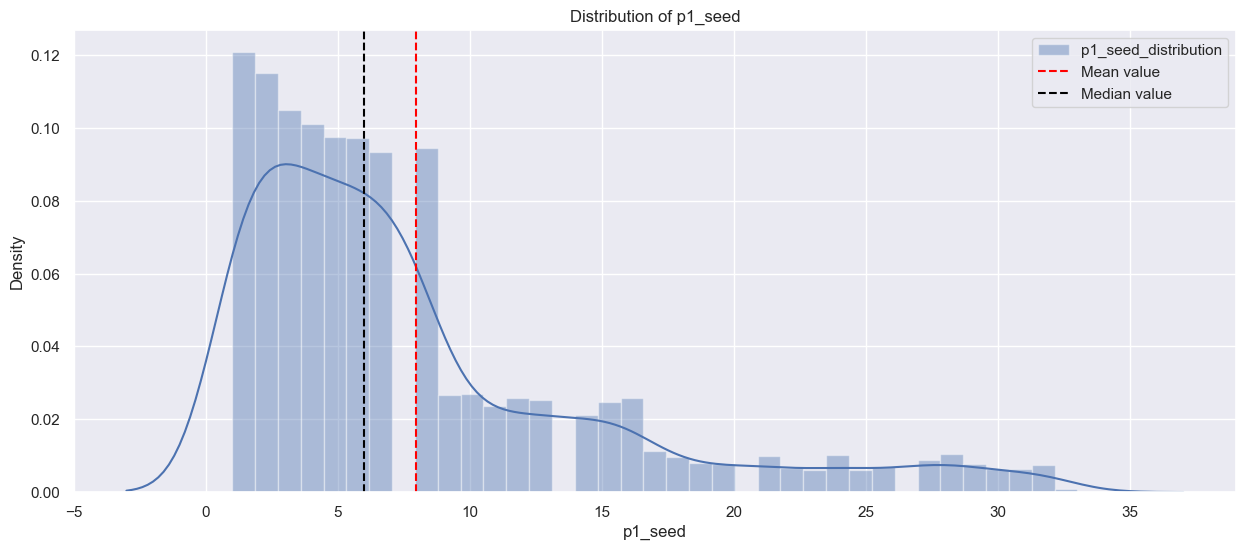

In [17]:
def plot_hist(data, column_name, log=False):
    vals = data[column_name]
    if log: vals = np.log(vals + np.finfo(float).eps)
    print('The mean value is :' , round(vals.mean(),2))
    print('The median value is :' , vals.median())
    plt.figure(figsize=(15,6))
    sns.distplot(vals, label=column_name + '_distribution')
    plt.axvline(x=vals.mean(), color='red', linestyle='--', label='Mean value')
    plt.axvline(x=vals.median(), color='black', linestyle='--', label='Median value')
    if log : plt.title('Distribution of ' + column_name + "_log")
    else: plt.title('Distribution of ' + column_name)
    plt.legend()
    plt.show()

numerical_features = ['p2_age', 'p2_ht', 'p2_rank', 'p2_rank_points', 'p2_seed',
       'match_num',  'p1_age', 'p1_ht', 'p1_id', 'p1_rank', 'p1_rank_points','p1_seed']
for col in numerical_features:
    plot_hist(data, col)

We can see on the above graphs that some of the features are right-skewed, applying the log function to these features will assure that we will get better predictions results on our model. If we ever going to use Tree Based models, this approach will allow us to have better splits in the different tree nodes

--------------------------------------------------------------------------------------------
### Date


In [18]:
data.tourney_date.min(), data.tourney_date.max() 

(20150104, 20190225)

In [19]:
df_time = data.copy()
df_time['tourney_date'] = pd.to_datetime(df_time['tourney_date'],format="%Y%m%d")
df_time['tourney_date'].min(), df_time['tourney_date'].max()

(Timestamp('2015-01-04 00:00:00'), Timestamp('2019-02-25 00:00:00'))

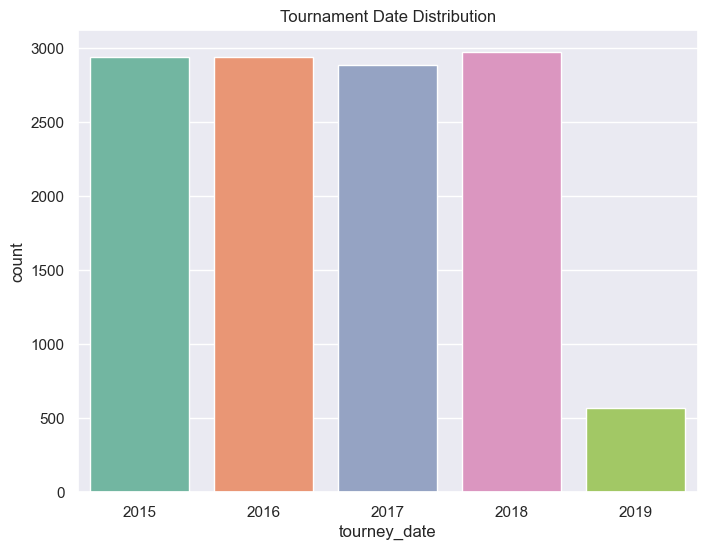

In [20]:
ax =sns.countplot(df_time["tourney_date"].dt.year, palette=sns.color_palette("Set2"))
ax.set_title("Tournament Date Distribution")
plt.show()

--------------------------------------------------------------------------------------------------------------
<a id = 'preprocessing'></a>
## 3. Preprocessing

To deal with our data and make them ready for the classifier model, we :
- Drop duplicates
- Drop redundant features.
- Drop features with more than 80% missing values.
- Deal with missing values.
- Split date into year, month and day
- Encode categorical features with low cardinality with OneHotEncoder.
- Encode categorical features with high cardinality with TargetEncoder.

We will drop "p1_name", "p2_name" and "torunament_name" because they are almost redundant and replaceable by respectively "p1_id", "p2_id" and "trouney_id" . <br>

### Missing values

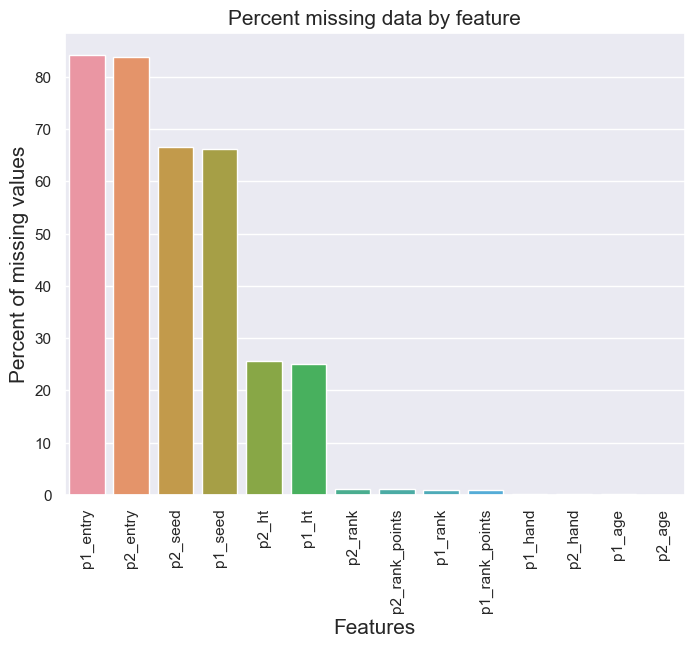

In [21]:
def display_missing_values(all_data):
    all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
    all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
    f, ax = plt.subplots(figsize=(8, 6))
    plt.xticks(rotation='90')
    sns.barplot(x=all_data_na.index, y=all_data_na)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Percent of missing values', fontsize=15)
    plt.title('Percent missing data by feature', fontsize=15)
    
display_missing_values(data)

We can see that we have a lot of null values, so we have to handle them.

We will remove feature that have more than 80% of None values.

Since "rank_points" and "rank", which contain past performance of players, and "surface" features are important ones, we will delete the entries that do not contain information about them.

In [22]:
class PreProcessing:
    """ Deal with missing values, drop useless columns and apply feature engineering"""
    
    def __init__(self, data: pd.DataFrame, features_to_drop:list[str], features_to_fill_by_median:list[str],\
         features_to_remove_nan_values:list[str], features_to_log:list[str]) -> None:
        self.data = data.copy()
        self.features_to_drop = features_to_drop
        self.features_to_fill_by_median = features_to_fill_by_median
        self.features_to_remove_nan_values = features_to_remove_nan_values
        self.features_to_log = features_to_log

    def preprocess(self) -> pd.DataFrame:
        """ Drop dupclicated, Apply missing values imputation

        Returns:
            pd.DataFrame: preprocessed data
        """

        print(f'''\n{'-'*20} Preprocessing data  {'-'*20}''')
        # drop duplicates
        print(f'''\nDrop duplicates''')
        self.data.drop_duplicates(inplace=True)
        # drop useless cols
        print(f'Drop redundant features, features with more than 80% missing values and features which cannot be known in advance of the match: {self.features_to_drop}')
        self.data.drop(columns=self.features_to_drop, axis=1, inplace=True)
        # fill nan values
        self._fill_nan_values()
        print('\nSplit Date into Year, Month and Day and extract new feature "is_weekend"')
        self._split_date()
        print(f'\nLog numerical features that are right skewed : {self.features_to_log}')
        self._log_features()
        print(f'\nData shape after cleaning and preprocessing : {self.data.shape}')
        print(f"\nRemained features : {list(self.data.columns)}")
        return self.data
        

    def _display_columns_with_nan_values(self) -> None:
        # sourcery skip: dict-comprehension
        """
        Find columns that contain nan values.
        """
        nb_rows = len(self.data)
        features_with_nan_values: dict[str, float] = {}
        for c in self.data.columns :
            if self.data[c].count() < nb_rows :
                features_with_nan_values[c] = round((1 - self.data[c].count() / nb_rows) * 100, 2)
           
        features_with_nan_values = {
            k: f'{str(v)}%'
            for k, v in sorted(
                features_with_nan_values.items(),
                key=lambda item: item[1],
                reverse=True,
            )
        }
        print(f'\nFeatures with missing values : {json.dumps(features_with_nan_values, indent = 4)}')   
        return None
 
    def _fill_nan_values(self) -> None:
        """ Impute missing values
        """
        self.data.replace(to_replace=['None'], value=None, inplace=True)
        self._display_columns_with_nan_values()

        print(f'\nImpute missing values with median for these features : {self.features_to_fill_by_median}')
        print(f'\nRemove rows with missing values for important features: {self.features_to_remove_nan_values}')
              
        # fill nan values by a median
        for c in self.features_to_fill_by_median:
            if self.data[c].count() > 0 :
                self.data[c] = self.data[c].fillna((self.data[c].median()))
            else: 
                self.data[c] = self.data[c].fillna(0)
        ## fillna for pi_hand with 'U' as there is already an unkonwn category
        self.data['p1_hand'] = self.data['p1_hand'].fillna('U')
        self.data['p2_hand'] = self.data['p2_hand'].fillna('U')
        self.data.reset_index(inplace=True, drop=True)

        # remove empty rows for important features in train set
        self.data.dropna(how='any',inplace=True) 

        self._display_columns_with_nan_values()
        return None
    
    def _split_date(self) -> None:
        """  Extract the year, the month and the day from the column tourney date. """
        self.data['tourney_date'] = pd.to_datetime(self.data['tourney_date'], format="%Y%m%d")
        self.data["day"] = self.data["tourney_date"].map(lambda x: x.day)
        self.data["month"] = self.data["tourney_date"].map(lambda x: x.month)
        self.data["year"] = self.data["tourney_date"].map(lambda x: x.year)
        self.data['is_weekend'] = self.data["tourney_date"].map(lambda x : 1 if x.weekday() >= 5 else 0)
        return

    def _log_features(self) -> None:
        """Log numerical features that are right skewed"""
        for feature in self.features_to_log:
            self.data[feature] = np.log(self.data[feature] + np.finfo(float).eps)


In [23]:
features_to_drop = ['tourney_name', 'p2_name', 'p1_name', 'p1_entry','p2_entry']
features_to_remove_nan_values = ['p1_rank_points', 'p2_rank_points', 'p1_rank', 'p2_rank', 'surface']
features_to_fill_by_median = [ 'p1_rank','p2_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 
                                'p2_rank_points', 'p2_age', 'p2_ht',  'p1_seed', 'p2_seed']
features_to_log = [ 'p2_rank', 'p2_rank_points', 'p2_seed','p1_id', 'p1_rank', 'p1_rank_points','p1_seed']

preprocessed_data = data.copy()
preprocessing = PreProcessing(preprocessed_data, features_to_drop,  \
    features_to_fill_by_median, features_to_remove_nan_values, features_to_log)
preprocessing.preprocess()
print(f'\nData shape after cleaning and preprocessing : {preprocessing.data.shape}')
preprocessed_data = preprocessing.data
print(f"\nremained features : {list(preprocessed_data.columns)}")


-------------------- Preprocessing data  --------------------

Drop duplicates
Drop redundant features, features with more than 80% missing values and features which cannot be known in advance of the match: ['tourney_name', 'p2_name', 'p1_name', 'p1_entry', 'p2_entry']

Features with missing values : {
    "p2_seed": "66.5%",
    "p1_seed": "66.13%",
    "p2_ht": "25.53%",
    "p1_ht": "25.09%",
    "p2_rank": "1.14%",
    "p2_rank_points": "1.14%",
    "p1_rank": "0.87%",
    "p1_rank_points": "0.87%",
    "surface": "0.65%",
    "p2_hand": "0.19%",
    "p1_hand": "0.19%",
    "p1_age": "0.07%",
    "p2_age": "0.04%"
}

Impute missing values with median for these features : ['p1_rank', 'p2_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 'p2_rank_points', 'p2_age', 'p2_ht', 'p1_seed', 'p2_seed']

Remove rows with missing values for important features: ['p1_rank_points', 'p2_rank_points', 'p1_rank', 'p2_rank', 'surface']

Features with missing values : {}

Split Date into Year, Month and D

In [24]:
print('The data columns types are :\n', preprocessed_data.dtypes)

The data columns types are :
 best_of                    int64
p2_age                   float64
p2_hand                   object
p2_ht                    float64
p2_id                      int64
p2_ioc                    object
p2_rank                  float64
p2_rank_points           float64
p2_seed                  float64
match_num                  int64
round                     object
surface                   object
tourney_date      datetime64[ns]
tourney_id                object
tourney_level             object
p1_age                   float64
p1_hand                   object
p1_ht                    float64
p1_id                    float64
p1_ioc                    object
p1_rank                  float64
p1_rank_points           float64
p1_seed                  float64
p1_won                     int64
day                        int64
month                      int64
year                       int64
is_weekend                 int64
dtype: object


In [25]:
preprocessed_data['p2_seed'].unique()

array([1.79175947e+00, 2.22044605e-16, 1.38629436e+00, 1.94591015e+00,
       6.93147181e-01, 1.09861229e+00, 2.56494936e+00, 3.09104245e+00,
       2.63905733e+00, 2.48490665e+00, 2.70805020e+00, 2.30258509e+00,
       1.60943791e+00, 2.07944154e+00, 3.46573590e+00, 2.19722458e+00,
       3.40119738e+00, 3.13549422e+00, 2.83321334e+00, 2.77258872e+00,
       2.89037176e+00, 2.39789527e+00, 2.99573227e+00, 3.25809654e+00,
       3.29583687e+00, 3.17805383e+00, 3.43398720e+00, 2.94443898e+00,
       3.21887582e+00, 3.04452244e+00, 3.49650756e+00, 3.33220451e+00,
       3.36729583e+00])

### Split data into train and test sets

In order to prepare our data for classification model, we need to split it into 80% for train and 20% and we need to take into consideration time dependancy
<img src="static/images/split.png" width="200" height="100">

In [26]:
def train_test_split_per_time(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """ Split data for training and test

    Args:
        data (pd.DataFrame): preprocessed data
    Returns:
        tuple[pd.DataFrame, pd.DataFrame, pd.Series,pd.Series]: X_train, X_test, y_train, y_test
    """

    print(f'''\n{'-'*20} Feature Engineering  {'-'*20}''')
    print(f'\nSplit Data into train and test data :')
    # sort by date before split
    data = data.sort_values('tourney_date')
    X = data.drop(columns=['p1_won'])
    y = data["p1_won"]
    # We have to not shuffle data to keep date sort
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    print(f'\nData Train shape : {X_train.shape}, from {min(X_train["tourney_date"])} to {max(X_train["tourney_date"])}')
    print(f'\nData Test shape : {X_test.shape}, from {min(X_test["tourney_date"])} to {max(X_test["tourney_date"])}')

    X_train.drop(columns=['tourney_date'], inplace=True)
    X_test.drop(columns=['tourney_date'], inplace=True)
    # reset_index
    X_train.reset_index(inplace=True, drop=True)
    y_train.reset_index(inplace=True, drop=True)
    X_test.reset_index(inplace=True, drop=True)
    y_test.reset_index(inplace=True, drop=True)
    
    return X_train, X_test, y_train, y_test

In [27]:
# Feature engineering
X_train, X_test, y_train, y_test = train_test_split_per_time(preprocessing.data)


-------------------- Feature Engineering  --------------------

Split Data into train and test data :

Data Train shape : (9784, 27), from 2015-01-04 00:00:00 to 2018-04-16 00:00:00

Data Test shape : (2446, 27), from 2018-04-16 00:00:00 to 2019-02-25 00:00:00


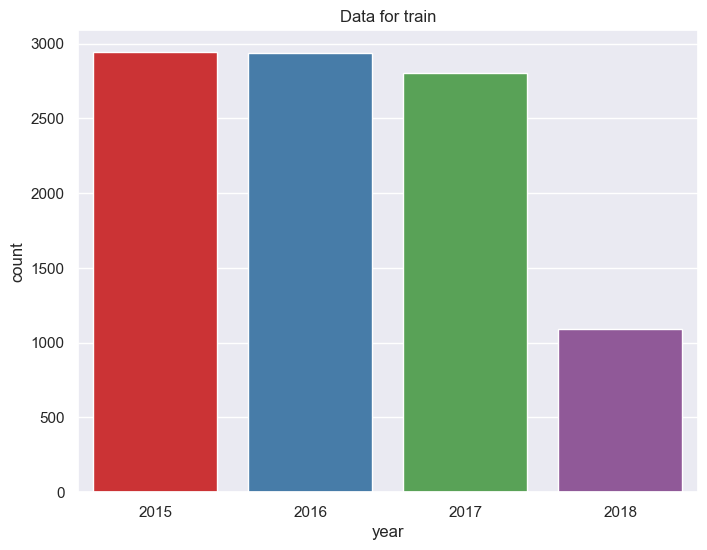

In [28]:
ax = sns.countplot(X_train['year'], palette= sns.color_palette('Set1'))
ax.set_title("Data for train")
plt.show()

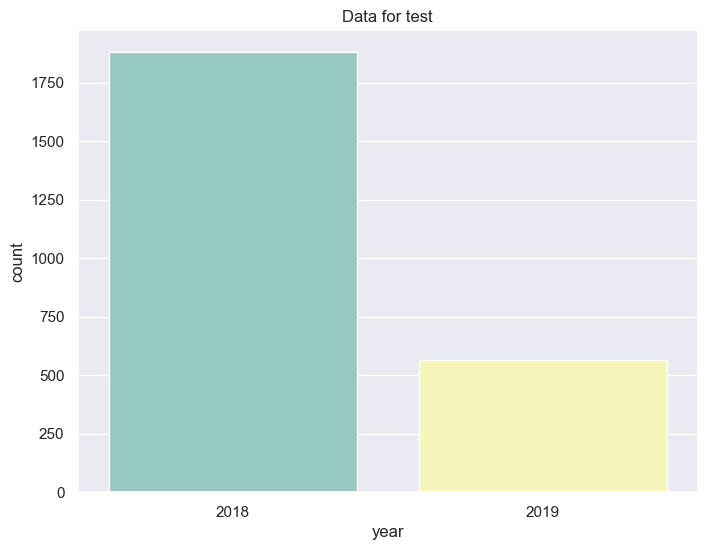

In [29]:
ax = sns.countplot(X_test['year'], palette = sns.color_palette('Set3'))
ax.set_title("Data for test")
plt.show()

--------------------------------------------------------------------------------------------------------------
<a id = 'engineering'></a>
## 3. Feature Engineering

For our prediction model, we have to encode categorical features.
 - Encode categorical features with **low cardinality** with **OneHotEncoder (OHE)**: It takes the categories and make them **binary values**. Using OHE in a dataset with too many variables will create a wide dataset as a separate column is created for each category in the variable. This can make the model more complex and slower to train.<br><br>
 
 - Encode categorical features with **high cardinality** (too many variables) with **TargetEncoder**. The main idea behind the target encoder is to encode the categories by **replacing them for a measurement of the effect they might have on the target**. This means we will replace each category by the value of the posterior probability of the target being 1 on the presence of that category. One popular **smoothing technique** is to take a combination of the target for the category and the global target mean for each data point. This technique is particularly useful to **avoid overfitting.** 
Adding some **random noise** to the column for each data point after target encoding the feature is another popular way of **handling the overfitting issue**.
<img src="static/images/target_encoder.PNG">

For numerical features, we will use **RobustScaler** which scale features using statistics that are robust to outliers.

This Scaler removes the median and scales the data according to the quantile range (defaults to IQR: Interquartile Range). The IQR is the range between the 1st quartile (25th quantile) and the 3rd quartile (75th quantile).

Centering and scaling happen independently on each feature by computing the relevant statistics on the samples in the training set.

<img src="static/images/robustscaler.PNG">

In [30]:
features_to_scale = [ 'p2_rank', 'p2_rank_points', 'p2_seed','p1_id', 'p1_rank', 'p1_rank_points','p1_seed',
'p1_age', 'p2_age', 'p1_ht', 'p2_ht',]
scaler = RobustScaler().fit(X_train[features_to_scale].values)
X_train[features_to_scale] = scaler.transform(X_train[features_to_scale].values)
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale].values)

In [31]:
low_cardinality_categorical_features = ['best_of', 'p2_hand',  'p1_hand', 'round', 'surface', 'tourney_level']
high_cardinality_categorical_features = ['p2_id', 'p1_id', 'p1_ioc', 'p2_ioc','tourney_id']

In [32]:
class OHEncoder:
    """ Encoding with OneHot Encoding for low cardinality categorical features """
    def __init__(self, low_cardinality_categorical_features: list[str]) -> None:
        self.low_cardinality_categorical_features = low_cardinality_categorical_features
        
    def get_onehot_encoder(self, X_train: pd.DataFrame):
        """ Create OneHot encoder and fit it with data train """
        oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
        oh_encoder.fit(X_train[self.low_cardinality_categorical_features])
        print(f'\nNew columns after encoding low cardinality categorical features with OneHotEncoder : {oh_encoder.get_feature_names_out()}')
        return oh_encoder
    
    def transfrom_with_ohe(self, X : pd.DataFrame, oh_encoder) -> pd.DataFrame:
        """ Transform data X using the onehot encoder oh_encoder

        Args:
            X (pd.DataFrame): data to be encoded
            oh_encoder (_type_): one hot encoder

        Returns:
            pd.DataFrame: encoded data
        """
        transformed_X = pd.DataFrame(oh_encoder.transform(X[self.low_cardinality_categorical_features]))
        transformed_X.columns = oh_encoder.get_feature_names_out()
        # One-hot encoding removed index; put it back
        transformed_X.index = X.index
        # Remove categorical columns (will replace with one-hot encoding)
        other_X_cols = X.drop(self.low_cardinality_categorical_features , axis=1)
        return pd.concat([other_X_cols, transformed_X], axis=1)


In [33]:
# OneHotEnconder
oh_encoder = OHEncoder(low_cardinality_categorical_features)
ohe = oh_encoder.get_onehot_encoder(X_train)
encoded_oh_X_train = oh_encoder.transfrom_with_ohe(X_train, ohe)
encoded_oh_X_test = oh_encoder.transfrom_with_ohe(X_test, ohe)


New columns after encoding low cardinality categorical features with OneHotEncoder : ['best_of_3' 'best_of_5' 'p2_hand_L' 'p2_hand_R' 'p2_hand_U' 'p1_hand_L'
 'p1_hand_R' 'p1_hand_U' 'round_BR' 'round_F' 'round_QF' 'round_R128'
 'round_R16' 'round_R32' 'round_R64' 'round_RR' 'round_SF'
 'surface_Carpet' 'surface_Clay' 'surface_Grass' 'surface_Hard'
 'tourney_level_A' 'tourney_level_D' 'tourney_level_F' 'tourney_level_G'
 'tourney_level_M']


In [34]:
class TargetEncoder:
    """ Encoding with Traget Encoding for high cardinality categorical features """
    def __init__(self) -> None:
        pass

    def get_target_encoder_params(self, X_train: pd.DataFrame, y_train : pd.Series, \
        high_cardinality_categorical_features: list[str]) -> dict[str, tuple[pd.DataFrame, float]]:
        """ Get parameters of the target encoder after fit with train set

        Args:
            X_train (pd.DataFrame): data train
            y_train (pd.Series): target

        Returns:
            _type_: parameters of target encoder
        """
        encoder_params : dict[str, tuple] = {}
        for feature in high_cardinality_categorical_features:
            averages, prior = TargetEncoder.get_target_encoder_parameters_per_feature(trn_series=X_train[feature], 
                                    target=y_train, 
                                    min_samples_leaf=100,
                                    smoothing=10)
            encoder_params[feature] = (averages, prior)
        return encoder_params

    @staticmethod
    def transform_with_target_encoder(X : pd.DataFrame, \
        encoder_params : dict[str, tuple[pd.DataFrame, float]])-> pd.DataFrame:
        """ Transform data with target encoder 

        Args:
            X (pd.DataFrame): data to be transformed
            encoder_params (_type_): parameters of encoder

        Returns:
            pd.DataFrame: transformed data
        """
        for feature, (averages, prior) in encoder_params.items():
            X[feature] = TargetEncoder.target_encode_one_feature(X[feature], averages, prior)

        return X

    @staticmethod
    def add_noise(series : pd.Series) -> pd.Series :
        """ Add some random gaussian noise to the column 
        for each data point after target encoding the feature 
        to handle the overfitting issue."""
        noise_level = 0.01
        return series * (1 + noise_level * np.random.randn(len(series)))

    @staticmethod
    def get_target_encoder_parameters_per_feature(trn_series=None,  
                    target=None, 
                    min_samples_leaf=1, 
                    smoothing=1) -> tuple[pd.DataFrame, float]:

        temp = pd.concat([trn_series, target], axis=1)
        
        # Compute target mean 
        averages = temp.groupby(by=trn_series.name)[target.name].agg(["mean", "count"])
        
        # Compute smoothing
        smoothing = 1 / (1 + np.exp(-(averages["count"] - min_samples_leaf) / smoothing))
        
        # Apply average function to all target data
        prior = target.mean()
        
        # The bigger the count the less full_avg is taken into account
        averages[target.name] = prior * (1 - smoothing) + averages["mean"] * smoothing
        averages.drop(["mean", "count"], axis=1, inplace=True)
        
        return averages, prior

    @staticmethod
    def target_encode_one_feature(X : pd.DataFrame, averages : pd.DataFrame, prior: float) -> pd.Series:
        """ Transform one feature with Target Encoder"""
        # Apply averages 
        ft_X= pd.merge(
            X.to_frame(X.name),
            averages.reset_index().rename(columns={'index': 'p1_won', 'p1_won': 'average'}),
            on=X.name,
            how='left')['average'].rename(X.name + '_mean').fillna(prior)

        # pd.merge does not keep the index so restore it
        ft_X.index = X.index 

        return TargetEncoder.add_noise(ft_X)


In [35]:
# Target Encoder
target_encoder = TargetEncoder()
target_encoder_params = target_encoder.get_target_encoder_params(X_train, y_train, high_cardinality_categorical_features)
encoded_X_train = target_encoder.transform_with_target_encoder(encoded_oh_X_train, target_encoder_params)
encoded_X_test = target_encoder.transform_with_target_encoder(encoded_oh_X_test, target_encoder_params)

In [36]:
encoded_X_test.head()

,p2_age,p2_ht,p2_id,p2_ioc,p2_rank,p2_rank_points,p2_seed,match_num,tourney_id,p1_age,...,round_SF,surface_Carpet,surface_Clay,surface_Grass,surface_Hard,tourney_level_A,tourney_level_D,tourney_level_F,tourney_level_G,tourney_level_M
0,-0.102041,-4.4,0.369353,0.462933,-1.263219,1.349428,0.000000,296,0.503081,-0.185714,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.658163,0.0,0.473046,0.455062,-0.346534,0.456338,0.000000,251,0.489173,0.528571,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.117347,1.0,0.489291,0.533278,0.236016,-0.189386,0.000000,247,0.496850,1.162185,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.136054,-0.8,0.497354,0.510927,0.040500,0.059751,-0.182322,290,0.494848,-1.007563,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.071429,0.0,0.486652,0.493716,0.365807,-0.274169,0.000000,286,0.483413,-0.182353,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


--------------------------------------------------------------------------------------------------------------
<a id = 'model'></a>
## 4. Model choice

In this part of the project, we will try different models to make the provided binary classification. We will start of by using a simple model like SVC and then try more advanced ones.

To compare the different models, We will divide the dataset into 3 folds using **TimeSeriesCrossValidation** then we will train on two on them and validate on the remaining one.
<img src="static/images/tscv.png">
We will add more metrics to that scoring function to have a better knowledge on the performance of the models.

#### Metrics :
The objective of our model is to make a binary classification on whether the first player will succeed or not. 

To do so, there are several binary classification metrics that can be used depending on the data distribution we have. <br> <br>
 
<b> Accuracy : </b> <br>
This is the simplest metric for binary classification. It measures the fraction of all instances that are correctly categorized; it is the ratio of the number of correct classifications to the total number of correct or incorrect classifications. <br> <br>

<center> Accuracy = $\frac{TP + TN}{Total Population} = \frac{TP + TN}{TP + TN + FP + FN}$ </center> <br> <br> <br>

<b> Precision : </b> <br>
Precision gives us an information on our binary classification model ability to identify only the relevant data points. <br> <br>

<center> Precision = $\frac{TP}{TP + FP}$ </center> <br> <br> <br>

<b> Recall : </b> <br>
Recall is an important metric when we deal with unbalanced dataset. This metric expresses the ability to find all relevant instances ( labeled 1 ) in a dataset. <br> <br>

<center> Recall = $\frac{TP}{TP + FN}$ </center> <br> <br> <br>

<b> F1-Score : </b> <br>
The F1 score is the harmonic mean of precision and recall taking both metrics into account in the following equation: <br> <br>

<center> F1 Score = $\frac{2 * Precision * Recall}{Precision + Recall}$ </center> <br> <br> <br>

<b> ROC AUC score : </b> <br>
AUC - ROC curve is a performance measurement for classification problem at various thresholds settings. ROC is a probability curve and AUC represents degree or measure of separability. It tells how much model is capable of distinguishing between classes. Higher the AUC, better the model is at predicting 0s as 0s and 1s as 1s. By analogy, Higher the AUC, better the model is at distinguishing between players that will succeed and those who won't.

In [37]:
def plot_conf_matrix(conf_matrix):
    df_cm = pd.DataFrame(conf_matrix.astype(int), range(2), range(2))
    plt.figure(figsize=(10,5))
    sns.set(font_scale=1)
    sns.heatmap(df_cm, annot=True, fmt='d')
    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [38]:
def evaluate_classifier(features_set: pd.DataFrame, classifier, labels: pd.Series) :
    """
    Performs 3 random trainings/tests to build a confusion matrix and prints results with precision and recall scores
    Inputs :
        - dataset : the dataset to work on
        - classifier : the classifier to use
        - labels : the labels used for training and validation
    :return:
    """
    
    n_splits = 3
    tscv = TimeSeriesSplit(n_splits)
    confusion_matrices = []
    recalls = []
    precisions = []
    accuracies = []
    f1_scores = []
    roc_auc = []
    train_duration = []
    predict_duration = []
    fold = 0
    # Sort train data by date
    dataset= features_set.copy()
    dataset['date'] = pd.to_datetime(dataset[['year', 'month', 'day']])
    dataset = dataset.sort_values('date')

    # Iterate through each split
    for train_index, test_index in tscv.split(dataset):
        
        cv_train_set, cv_test_set = dataset.iloc[train_index], dataset.iloc[test_index]
        cv_train_label, cv_test_label = labels.iloc[train_index], labels.iloc[test_index]

    
        print('Fold :', fold)
        print('Train date range: from {} to {}'.format(cv_train_set.date.min(), cv_train_set.date.max()))
        print('Test date range: from {} to {}\n'.format(cv_test_set.date.min(), cv_test_set.date.max()))
        fold += 1
        cv_train_set.drop(columns=['date'], inplace=True)
        cv_test_set.drop(columns=['date'], inplace=True)
        
        
        start_train = time()
        classifier.fit(cv_train_set, cv_train_label)
        end_train = time()
        train_duration.append(end_train - start_train)
        
        start_predict=time()
        predicted_labels = classifier.predict(cv_test_set)
        end_predict = time()
        predict_duration.append(end_predict - start_predict)
        confusion_matrices.append(confusion_matrix(cv_test_label, predicted_labels))
        recalls.append(recall_score(cv_test_label, predicted_labels))
        precisions.append(precision_score(cv_test_label, predicted_labels))
        f1_scores.append(f1_score(cv_test_label, predicted_labels))
        accuracies.append(accuracy_score(cv_test_label, predicted_labels))
        roc_auc.append(roc_auc_score(cv_test_label, predicted_labels))
    
    recall = np.mean(recalls) 
    precision = np.mean(precisions)
    accuracy = np.mean(accuracies)
    f1_sc = np.mean(f1_scores)
    roc_auc = np.mean(roc_auc)
    confusion_mat = np.mean(confusion_matrices, axis=0)
    train_duration = np.mean(train_duration)
    predict_duration = np.mean(predict_duration)
    
    print(f"Recall = {recall}")
    print(f"Precision = {precision}")
    print(f"Accuracy = {accuracy}")
    print(f'ROC AUC score ={roc_auc} ')
    print(f"f1 score = {f1_sc}")  
    print(f'Train duration (sec) ={train_duration} ')
    print(f'Prediction duration (sec) ={predict_duration} ')
    plot_conf_matrix(confusion_mat)
    print("*"*100)
    print("*"*100)
    return f1_sc, train_duration, predict_duration
    

Support Vector Classifier results : 

Fold : 0
Train date range: from 2015-01-04 00:00:00 to 2015-09-18 00:00:00
Test date range: from 2015-09-18 00:00:00 to 2016-07-18 00:00:00

Fold : 1
Train date range: from 2015-01-04 00:00:00 to 2016-07-18 00:00:00
Test date range: from 2016-07-18 00:00:00 to 2017-05-29 00:00:00

Fold : 2
Train date range: from 2015-01-04 00:00:00 to 2017-05-29 00:00:00
Test date range: from 2017-05-29 00:00:00 to 2018-04-16 00:00:00

Recall = 0.3282743038614171
Precision = 0.5013033246351286
Accuracy = 0.49986372308530935
ROC AUC score =0.501410180646217 
f1 score = 0.3743719357640212
Train duration (sec) =11.684788783391317 
Prediction duration (sec) =1.4209054311116536 


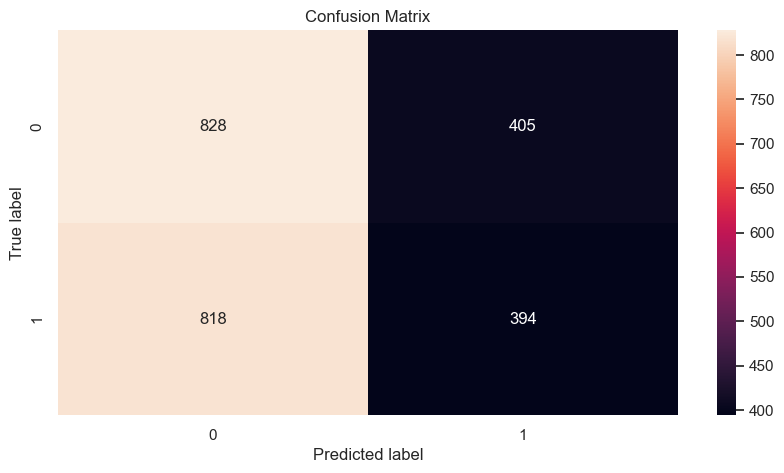

****************************************************************************************************
****************************************************************************************************
DecisionTreeClassifier results : 

Fold : 0
Train date range: from 2015-01-04 00:00:00 to 2015-09-18 00:00:00
Test date range: from 2015-09-18 00:00:00 to 2016-07-18 00:00:00

Fold : 1
Train date range: from 2015-01-04 00:00:00 to 2016-07-18 00:00:00
Test date range: from 2016-07-18 00:00:00 to 2017-05-29 00:00:00

Fold : 2
Train date range: from 2015-01-04 00:00:00 to 2017-05-29 00:00:00
Test date range: from 2017-05-29 00:00:00 to 2018-04-16 00:00:00

Recall = 0.4920881015124434
Precision = 0.5015532670467299
Accuracy = 0.5055873535023166
ROC AUC score =0.50569414749438 
f1 score = 0.49652996195213994
Train duration (sec) =0.09653870264689128 
Prediction duration (sec) =0.0 


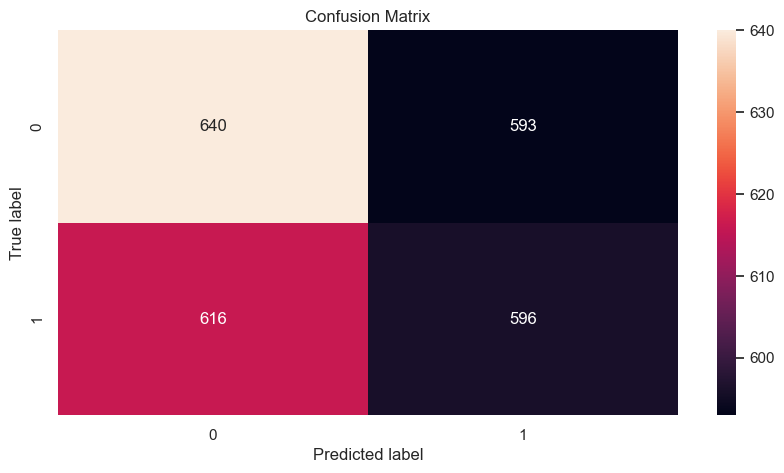

****************************************************************************************************
****************************************************************************************************
RandomForestClassifier results : 

Fold : 0
Train date range: from 2015-01-04 00:00:00 to 2015-09-18 00:00:00
Test date range: from 2015-09-18 00:00:00 to 2016-07-18 00:00:00

Fold : 1
Train date range: from 2015-01-04 00:00:00 to 2016-07-18 00:00:00
Test date range: from 2016-07-18 00:00:00 to 2017-05-29 00:00:00

Fold : 2
Train date range: from 2015-01-04 00:00:00 to 2017-05-29 00:00:00
Test date range: from 2017-05-29 00:00:00 to 2018-04-16 00:00:00

Recall = 0.492350714658157
Precision = 0.5006457423772465
Accuracy = 0.5044971381847915
ROC AUC score =0.5047264990459142 
f1 score = 0.49481498105991895
Train duration (sec) =0.922027587890625 
Prediction duration (sec) =0.03825092315673828 


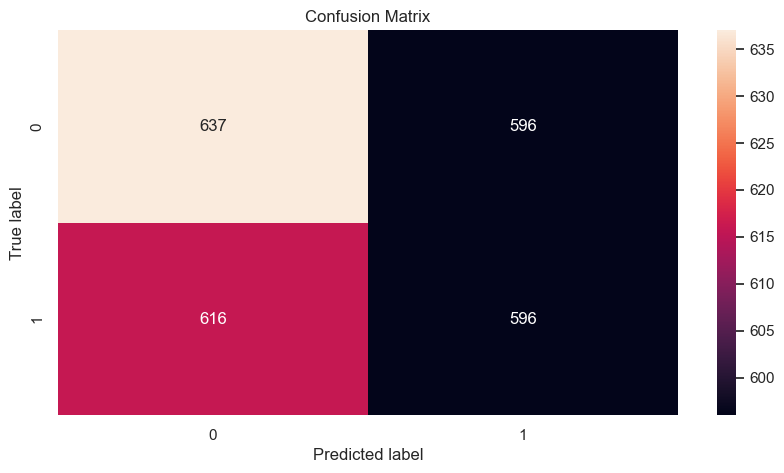

****************************************************************************************************
****************************************************************************************************
LGBMClassifier results : 

Fold : 0
Train date range: from 2015-01-04 00:00:00 to 2015-09-18 00:00:00
Test date range: from 2015-09-18 00:00:00 to 2016-07-18 00:00:00

Fold : 1
Train date range: from 2015-01-04 00:00:00 to 2016-07-18 00:00:00
Test date range: from 2016-07-18 00:00:00 to 2017-05-29 00:00:00

Fold : 2
Train date range: from 2015-01-04 00:00:00 to 2017-05-29 00:00:00
Test date range: from 2017-05-29 00:00:00 to 2018-04-16 00:00:00

Recall = 0.5139429326240667
Precision = 0.4958482792805443
Accuracy = 0.5001362769146906
ROC AUC score =0.499598832838221 
f1 score = 0.5033072912658314
Train duration (sec) =0.11056200663248698 
Prediction duration (sec) =0.00538325309753418 


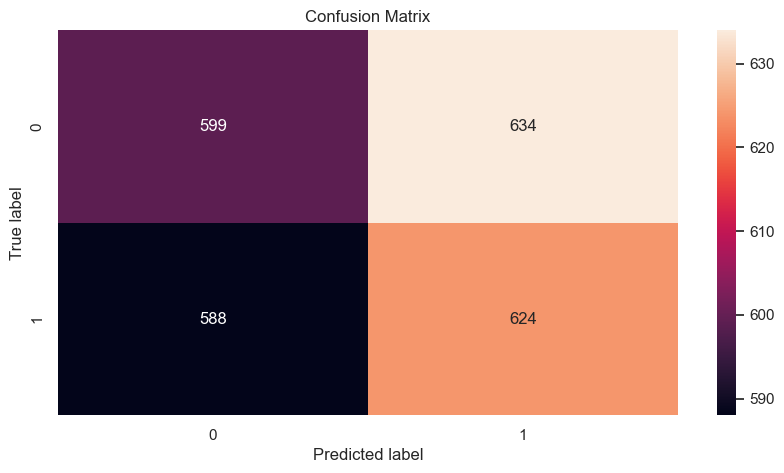

****************************************************************************************************
****************************************************************************************************
XGBClassifier results : 

Fold : 0
Train date range: from 2015-01-04 00:00:00 to 2015-09-18 00:00:00
Test date range: from 2015-09-18 00:00:00 to 2016-07-18 00:00:00

Fold : 1
Train date range: from 2015-01-04 00:00:00 to 2016-07-18 00:00:00
Test date range: from 2016-07-18 00:00:00 to 2017-05-29 00:00:00

Fold : 2
Train date range: from 2015-01-04 00:00:00 to 2017-05-29 00:00:00
Test date range: from 2017-05-29 00:00:00 to 2018-04-16 00:00:00

Recall = 0.495913794251213
Precision = 0.4904893420730964
Accuracy = 0.494140092668302
ROC AUC score =0.49385455805977435 
f1 score = 0.4927755111212296
Train duration (sec) =0.2452223300933838 
Prediction duration (sec) =0.0026655197143554688 


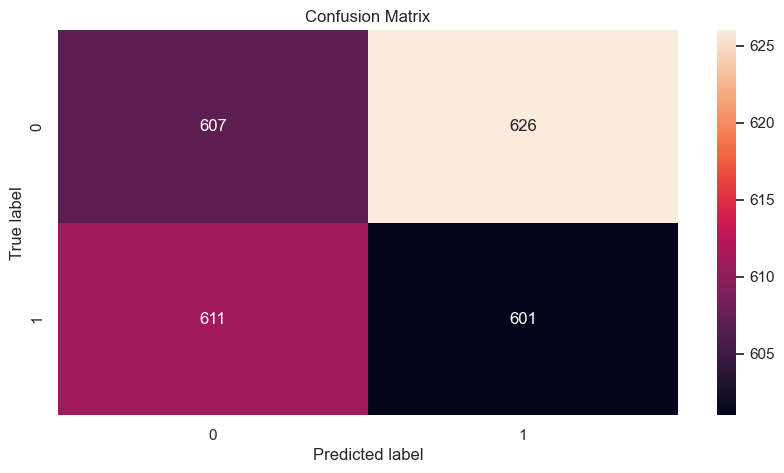

****************************************************************************************************
****************************************************************************************************


In [39]:
models = {'Support Vector Classifier': SVC(gamma='auto', probability=True),
          'DecisionTreeClassifier':DecisionTreeClassifier(),
          'RandomForestClassifier': RandomForestClassifier(), 
          'LGBMClassifier': LGBMClassifier(),
          'XGBClassifier':XGBClassifier()
       }

scores =  []
for model_name, model in models.items():
    print(model_name + " results : \n")
    score, train_duration, predict_duration = evaluate_classifier(encoded_X_train, model, y_train)
    scores.append((model_name, score, train_duration, predict_duration))
    

In [40]:
cols = ["Classifier", "f1_score", "Train duration (sec)", "Prediction duration (sec)"]
print(f'Models comparison based on f1_score and train duration : \n')
pd.DataFrame.from_records(scores, columns=cols)



Models comparison based on f1_score and train duration : 



,Classifier,f1_score,Train duration (sec),Prediction duration (sec)
0,Support Vector Classifier,0.374372,11.684789,1.420905
1,DecisionTreeClassifier,0.496530,0.096539,0.000000
2,RandomForestClassifier,0.494815,0.922028,0.038251
3,LGBMClassifier,0.503307,0.110562,0.005383
4,XGBClassifier,0.492776,0.245222,0.002666


The model who has the best f1 score is the LightGBM model, with a f1 score equal to 0.5. The other models that also performed well are DecisionTree, RandomForest and XGBoost. As we can notice also, LightGBM was the second faster model after DecisionTree.
<br>


So, the model we will work with is : **LightGBM** which is a gradient boosting framework that uses tree based learning algorithms. It is designed to be distributed and efficient with the following advantages:

- Faster training speed and higher efficiency.
- Lower memory usage.
- Support of parallel, distributed, and GPU learning.


In [41]:
def display_classification_result(y_true, y_pred):
    """
    Display evaluation metrics 
    """

    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1s = f1_score(y_true, y_pred)
    report = (acc, pre, rec, f1s)
    reports = [report]
    print(f'{pd.DataFrame.from_records(reports, columns=metrics)}')
    

--------------------------------------------------------------------------------------------------------------
<a id = 'train'></a>
### 5. Fine Tuning and Train

We use Grid search to fine these hyperparameters
- max_depth : It describes the maximum depth of tree. This parameter is used to handle model overfitting. If you feel that your model is overfitted, you should to lower max_depth.
- num_leaves: the maximum number of leaves per tree.
- learning_rate : determines the step size at each iteration while moving toward a minimum of a loss function
- n_estimators : Number of boosted trees to fit.
 


Let us apply the **GridSearchCV** to find the optimum values for parameters in LightGBM. GridSearchCV is an algorithm that takes different values for the specified parameters and then returns the optimum combinations.For Cross Validation, we will use **TimeSeries CrossValidation**.



In [42]:
def fine_tune_best_model(X_train : pd.DataFrame , y_train: pd.DataFrame) -> LGBMClassifier:
    """ Train and finetune model

        Args:
            X_train (pd.DataFrame): Data Train
            y_train (pd.DataFrame): Data target

        Returns:
            LGBMClassifier: trained and fine tuned model
    """  

    model = LGBMClassifier
    # Fine Tunning 
    print(f'''\n{'-'*20} Finetune model with Time Series Cross Validation {'-'*20}''')
    n_splits = 2
    tscv = TimeSeriesSplit(n_splits)
    cv = GridSearchCV(
            estimator=model(),
            param_grid={'num_leaves': (15, 31, 45, 70),
                        'max_depth': (3, 5, 7, 10),
                        'learning_rate': (0.001, 0.01, 0.1, 1.0),
                        'n_estimators': (25, 50, 100, 200, 300)
                       },
            scoring='f1',
            cv=tscv,
            n_jobs=2,
            verbose=1,
            refit=True
            )

    cv.fit(X_train,y_train)
    print(f"\nBest parameters : {cv.best_params_}")
    best_model = model(**cv.best_params_)
    print(f"\nTrain LightGBM model with best parameters : {cv.best_params_}")
    best_model.fit(X_train, y_train)
    return best_model   

In [43]:
model_best_hyperp = fine_tune_best_model(encoded_X_train, y_train)


-------------------- Finetune model with Time Series Cross Validation --------------------
Fitting 2 folds for each of 320 candidates, totalling 640 fits

Best parameters : {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 25, 'num_leaves': 31}

Train LightGBM model with best parameters : {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 25, 'num_leaves': 31}


--------------------------------------------------------------------------------------------------------------
<a id = 'predict'></a>
### 6. Evaluation

We will evaluate our model on our Test test before and after fine tuning.

In [53]:
basic_model = LGBMClassifier()
evals_result ={}
basic_model.fit(encoded_X_train, y_train)
# prediction
y_pred = basic_model.predict(encoded_X_test)
display_classification_result(y_test, y_pred)

   Accuracy  Precision    Recall  F1-Score
0  0.620196    0.64958  0.601556  0.624646


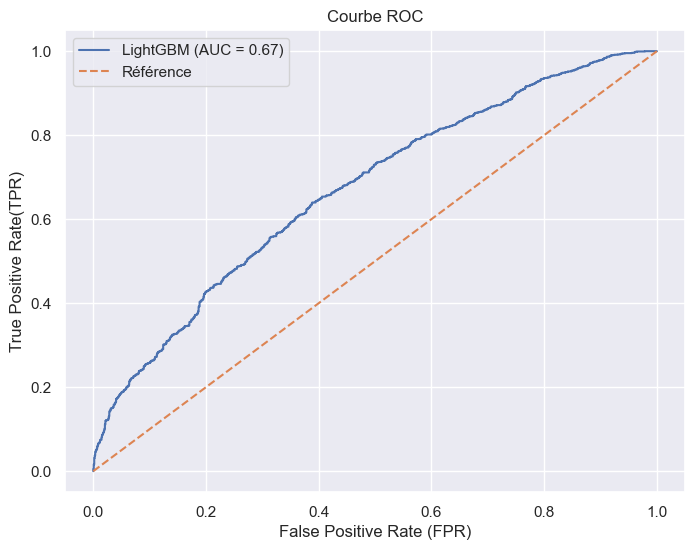

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score


# Prédire les probabilités des classes positives pour les données de test
y_pred_proba = basic_model.predict_proba(encoded_X_test)[:, 1]

# Calculer les valeurs de taux de faux positifs (FPR) et de taux de vrais positifs (TPR) pour différents seuils de classification
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculer l'aire sous la courbe ROC (AUC)
auc = roc_auc_score(y_test, y_pred_proba)

# Dessiner la courbe ROC
plt.plot(fpr, tpr, label='LightGBM (AUC = {:.2f})'.format(auc))
plt.plot([0, 1], [0, 1], linestyle='--', label='Référence')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate(TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.show()

In [52]:
LGBMClassifier.fit?

In [45]:
# prediction after fine tuning
y_pred = model_best_hyperp.predict(encoded_X_test)
display_classification_result(y_test, y_pred)

   Accuracy  Precision    Recall  F1-Score
0  0.630417   0.664366  0.599222  0.630115


In [46]:
from lightgbm import plot_metric
plot_metric(basic_model)

TypeError: object of type 'NoneType' has no len()

In [ ]:
plot_conf_matrix(confusion_matrix(y_test, y_pred))

As we can notice, using GridSearch with TimeSeries Cross Validation has improved the performance of the model 

We will use SHAP (SHapley Additive exPlanations) library which is a game theoretic approach to explain the output of any machine learning model. It will allow as visualize the behaviour of the classifer as well as the most important features used.

In [ ]:
!pip install --upgrade shap

In [ ]:
# explication of model results with shap values
explainer = shap.TreeExplainer(model_best_hyperp)
shap_values = explainer.shap_values(encoded_X_test)
shap.summary_plot(shap_values[0], encoded_X_test)


This plot allows as to get an overview of which features are most important for a model. "id", "rank" and "rank_points" are the most important features. This is expected as those features express directly the id and the level of performance of each player.

The color represents the feature value (red high, blue low). This reveals for example that a high p1_rank (rank of first player) lowers the predicted labels (label tends vers 0).

--------------------------------------------------------------------------------------------------------------
<a id = 'conclusion'></a>
### 7. Conclusion

The F1 score of 63% we've got can be explained by the fact that the nature of the problem. However, we can improve it by :
- Make more data preprocessing and feature engineering such as :
    - Impute missing values with the intersection of information for the same player in other matches.
    - Extract the number of matches won previously by a player.
- Apply more accurate Encoding for categorical features such as the feature 'Tourney_name' or 'Tourney_id' instead of droping this information.
- Normalize the numerical features.
- Deal with outliers.
- More consider the time dependency.
- More investigate in the fetaures description in order to extract more feature and also try a better way for feature selection.
- Make predictions during the match by adding information about the current situation.
- Improve the web interface and add more transformation on the input of the user in the interface